# Job Market Intelligence – Exploratory Data Analysis

This notebook explores the cleaned No Fluff Jobs dataset to identify patterns in job demand, experience levels, workplace models, contract types, salaries, and technologies.

In [1]:
from pathlib import Path

import pandas as pd
import plotly.express as px
import re

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "nofluff_it_jobs_clean.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)


Dataset shape: (3360, 37)


## Analysis plan

The exploratory analysis focuses on five main questions:

1. What experience levels are most in demand?
2. What workplace models and contract types are most common?
3. Which job categories and companies show the highest recruitment activity?
4. How do salaries differ across experience levels, categories and employment conditions?
5. Which technologies and skills are most frequently required?


## 1. Dataset overview

This section provides a high-level overview of the dataset, including the number
of job offers, companies, categories, salary availability, and data collection period.


In [2]:
# Convert scraping date to datetime
df["scraped_at"] = pd.to_datetime(
    df["scraped_at"],
    errors="coerce"
)

overview = pd.Series({
    "Job offers": len(df),
    "Unique companies": df["company"].nunique(),
    "Unique job titles": df["title"].nunique(),
    "Unique categories": df["category"].nunique(),
    "Offers with salary": df["salary_min"].notna().sum(),
    "Salary analysis eligible": df["salary_analysis_eligible"].sum(),
})

overview

Job offers                  3360
Unique companies             373
Unique job titles           2695
Unique categories             35
Offers with salary          2352
Salary analysis eligible    2352
dtype: int64

In [3]:
salary_available_pct = (
    df["salary_min"].notna().mean() * 100
)

salary_eligible_pct = (
    df["salary_analysis_eligible"].mean() * 100
)

print(
    f"Offers with salary: "
    f"{salary_available_pct:.1f}%"
)

print(
    f"Offers eligible for salary analysis: "
    f"{salary_eligible_pct:.1f}%"
)

print()
print(
    "Data collection period:",
    df["scraped_at"].min().date(),
    "to",
    df["scraped_at"].max().date()
)

Offers with salary: 70.0%
Offers eligible for salary analysis: 70.0%

Data collection period: 2026-08-24 to 2026-08-26


In [4]:
df[
    [
        "title",
        "company",
        "experience",
        "workplace",
        "salary_min",
        "salary_max"
    ]
].head()

,title,company,experience,workplace,salary_min,salary_max
0,1st Line Analyst with English,DCG,Junior,Remote,5900.0,6400.0
1,Administrator IT,iteo S.A.,Mid,NaN,10000.0,13000.0
2,Administrator/-ka Aplikacji Biznesowych - Depa...,T-Mobile Polska,Mid,Hybrid,NaN,NaN
3,ADMINISTRATOR SAP BASIS (k/m),MODIVO PLATFORM,Mid,Onsite,NaN,NaN
4,Administrator Systemów IT,Upvanta,Mid,NaN,500.0,650.0


### Key observations

- The cleaned dataset contains 3,360 unique job offers collected between August 24 and August 26, 2026.
- It contains 373 source company names, 2,695 unique job titles and 35 standardized job categories.
- Salary information suitable for period and currency normalization is available for 2,352 offers (70.0%).
- The remaining salary records are retained in the dataset but are not used in standardized salary comparisons.
- The dataset is a cross-sectional market snapshot rather than a time series.


## 2. Experience level

This section examines the distribution of job offers across different experience levels.

In [5]:
experience_counts = (
    df["experience"]
    .value_counts(dropna=False)
    .to_frame("job_offers")
)

experience_counts

,job_offers
experience,
Senior,1816
Mid,1230
Expert,144
Junior,142
NaN,28


In [6]:
experience_summary = (
    df["experience"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("experience")
    .reset_index(name="job_offers")
)

experience_summary["percentage"] = (
    experience_summary["job_offers"]
    / len(df)
    * 100
).round(1)

experience_summary

,experience,job_offers,percentage
0,Senior,1816,54.0
1,Mid,1230,36.6
2,Expert,144,4.3
3,Junior,142,4.2
4,Missing,28,0.8


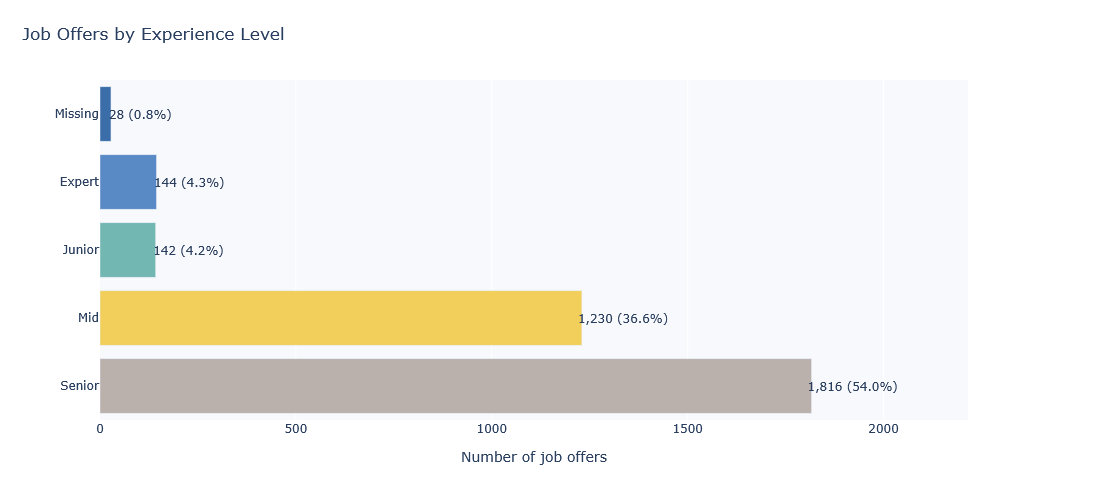

In [7]:
experience_order = [
    "Senior",
    "Mid",
    "Junior",
    "Expert",
    "Missing",
]

experience_summary = (
    df["experience"]
    .fillna("Missing")
    .value_counts()
    .reindex(
        experience_order,
        fill_value=0,
    )
    .rename_axis("experience")
    .reset_index(name="job_offers")
)

experience_summary["percentage"] = (
    experience_summary["job_offers"]
    / len(df)
    * 100
).round(1)

experience_summary["label"] = (
    experience_summary["job_offers"]
    .map(lambda value: f"{value:,}")
    + " ("
    + experience_summary["percentage"].map(
        lambda value: f"{value:.1f}%"
    )
    + ")"
)

fig = px.bar(
    experience_summary,
    x="job_offers",
    y="experience",
    orientation="h",
    text="label",
    category_orders={
        "experience": list(
            reversed(experience_order)
        )
    },
    title="Job Offers by Experience Level",
    labels={
        "job_offers": "Number of job offers",
        "experience": "Experience level",
    },
    color="experience",
    color_discrete_sequence=[
        "#3B6EA8",
        "#5A8AC6",
        "#72B7B2",
        "#F2CF5B",
        "#BAB0AC",
    ],
)

fig.update_traces(
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Job offers: %{x:,}"
        "<extra></extra>"
    ),
)

fig.update_layout(
    width=1000,
    height=480,
    showlegend=False,
    plot_bgcolor="#F7F9FC",
    title=dict(
        x=0.02,
        xanchor="left",
    ),
    xaxis=dict(
        title="Number of job offers",
        range=[
            0,
            experience_summary["job_offers"].max() * 1.22,
        ],
        gridcolor="white",
        zeroline=False,
    ),
    yaxis=dict(
        title=None,
    ),
    margin=dict(
        l=100,
        r=140,
        t=80,
        b=60,
    ),
)

fig.show()

In [8]:
df['experience_years_min'].describe()

count    1793.000000
mean        4.773564
std         1.988537
min         1.000000
25%         3.000000
50%         5.000000
75%         5.000000
max        15.000000
Name: experience_years_min, dtype: float64

In [9]:
df.groupby('experience')['experience_years_min'].describe()

,count,mean,std,min,25%,50%,75%,max
experience,,,,,,,,
Expert,80.0,7.037500,2.477462,3.0,5.0,7.0,8.0,15.0
Junior,49.0,3.346939,2.487896,1.0,2.0,2.0,5.0,12.0
Mid,636.0,3.734277,1.717026,1.0,3.0,3.0,5.0,10.0
Senior,1027.0,5.311587,1.689981,1.0,5.0,5.0,6.0,15.0


In [10]:
experience_years = (
    df.groupby("experience")["experience_years_min"]
    .agg(
        job_offers="count",
        median_years="median",
        mean_years="mean"
    )
    .round(1)
)

experience_years

,job_offers,median_years,mean_years
experience,,,
Expert,80,7.0,7.0
Junior,49,2.0,3.3
Mid,636,3.0,3.7
Senior,1027,5.0,5.3


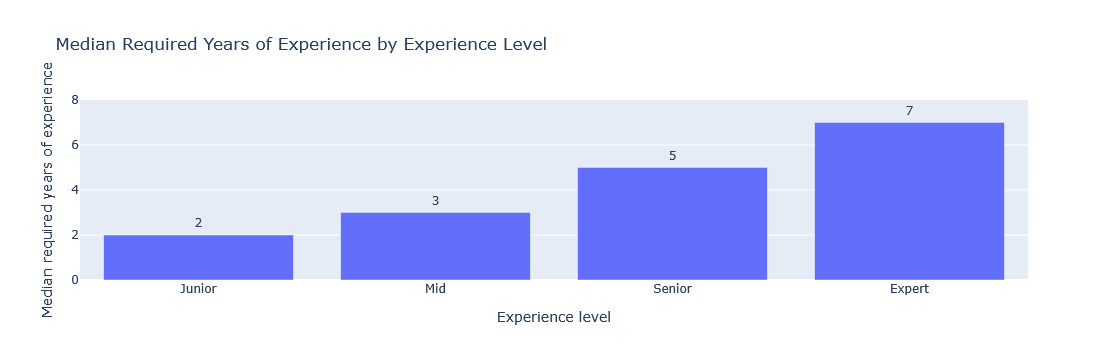

In [11]:

experience_order = [
    "Junior",
    "Mid",
    "Senior",
    "Expert"
]

median_experience = (
    df.groupby("experience")["experience_years_min"]
    .median()
    .reindex(experience_order)
    .reset_index()
)

fig = px.bar(
    median_experience,
    x="experience",
    y="experience_years_min",
    text="experience_years_min",
    title="Median Required Years of Experience by Experience Level",
    labels={
        "experience": "Experience level",
        "experience_years_min": "Median required years"
    }
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    showlegend=False,
    yaxis_title="Median required years of experience",
    xaxis_title="Experience level"
)

fig.update_yaxes(
    range=[0, 8]
)

fig.show()

## 3. Workplace Models

This section examines the distribution of remote, hybrid and onsite job offers and compares workplace models across experience levels.

In [12]:
workplace_summary = (
    df["workplace"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("workplace")
    .reset_index(name="job_offers")
)

workplace_summary["percentage"] = (
    workplace_summary["job_offers"]
    / len(df)
    * 100
).round(1)

workplace_summary

,workplace,job_offers,percentage
0,Hybrid,1880,56.0
1,Remote,1180,35.1
2,Missing,290,8.6
3,Onsite,10,0.3


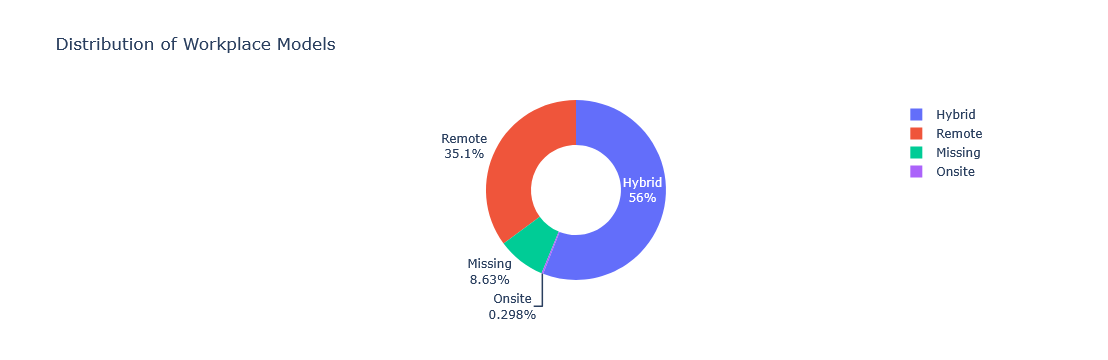

In [13]:
fig = px.pie(
    workplace_summary,
    names="workplace",
    values="job_offers",
    hole=0.5,
    title="Distribution of Workplace Models"
)

fig.update_traces(
    textinfo="percent+label",
    insidetextorientation="horizontal"
)

fig.show()

In [14]:
workplace_experience = (
    pd.crosstab(
        df["experience"],
        df["workplace"].fillna("Missing"),
        normalize="index"
    )
    * 100
).round(1)

workplace_experience

workplace,Hybrid,Missing,Onsite,Remote
experience,,,,
Expert,65.3,2.8,0.0,31.9
Junior,63.4,16.2,0.0,20.4
Mid,58.1,13.3,0.7,27.9
Senior,53.1,5.0,0.0,41.9


In [15]:
workplace_experience_plot = (
    workplace_experience
    .reset_index()
    .melt(
        id_vars="experience",
        var_name="workplace",
        value_name="percentage"
    )
)

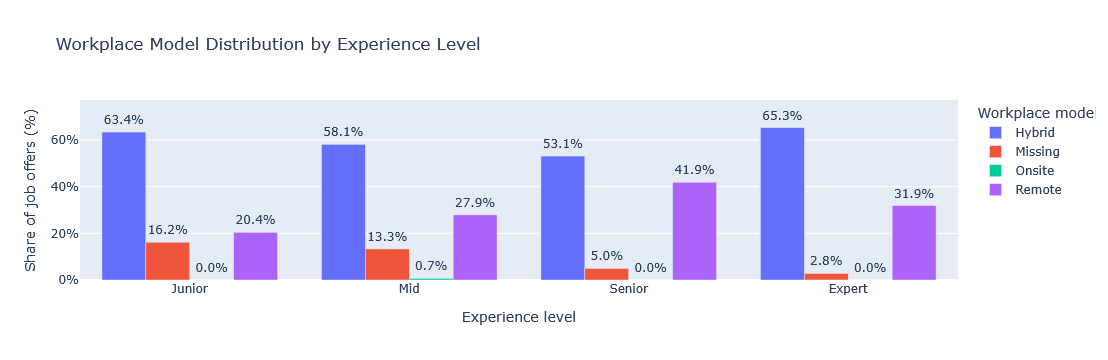

In [16]:
fig = px.bar(
    workplace_experience_plot,
    x="experience",
    y="percentage",
    color="workplace",
    text="percentage",
    barmode="group",
    category_orders={
        "experience": [
            "Junior",
            "Mid",
            "Senior",
            "Expert"
        ]
    },
    title="Workplace Model Distribution by Experience Level",
    labels={
        "experience": "Experience level",
        "percentage": "Share of job offers (%)",
        "workplace": "Workplace model"
    }
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

fig.update_layout(
    yaxis_ticksuffix="%"
)

fig.show()

### Key observations

Senior and Mid-level positions dominate the dataset, jointly accounting for 90.6% of all offers. Senior roles represent 54.0% of the market and Mid-level roles 36.6%.

Junior positions account for only 4.2% of offers, indicating limited entry-level availability. Expert roles represent 4.3%, while experience information is missing for 0.8% of records.

Hybrid work is the most common workplace model, representing 56.0% of offers. Remote positions account for 35.1%, missing workplace information for 8.6%, and Onsite offers for only 0.3%.

Remote work accounts for 41.9% of Senior offers, compared with 27.9% of Mid and 20.4% of Junior offers. Junior candidates are more strongly concentrated in Hybrid roles, which represent 63.4% of their offers.

Overall, recruitment activity is strongly oriented toward experienced professionals, who also appear to have greater access to fully remote opportunities.


## 4. Job categories

This section examines recruitment activity and experience-level composition across the standardized job categories.


In [17]:
category_summary = (
    df["category"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("category")
    .reset_index(name="job_offers")
)

category_summary.head(20)


,category,job_offers
0,Backend,625
1,Data,430
2,Testing,268
3,DevOps,264
4,Fullstack,253
5,AI,187
6,ERP,175
7,Project Manager,168
8,Security,155
9,Architecture,153


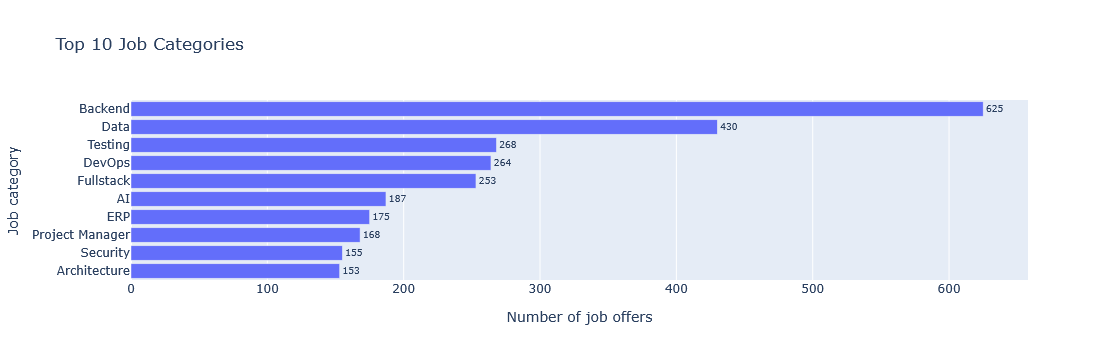

In [18]:
top_10_categories = (
    category_summary
    .head(10)
    .sort_values(
        "job_offers",
        ascending=True,
    )
)

fig = px.bar(
    top_10_categories,
    x="job_offers",
    y="category",
    orientation="h",
    text="job_offers",
    title="Top 10 Job Categories",
    labels={
        "job_offers": "Number of job offers",
        "category": "Job category",
    },
)

fig.update_traces(textposition="outside")
fig.update_layout(showlegend=False)
fig.show()


In [19]:
top_10_category_names = (
    category_summary
    .head(10)["category"]
    .tolist()
)

category_experience_df = (
    df.loc[
        df["category"].isin(top_10_category_names),
        ["job_id", "category", "experience"],
    ]
    .dropna(subset=["experience"])
)


In [20]:
category_experience = (
    pd.crosstab(
        category_experience_df["category"],
        category_experience_df["experience"],
        normalize="index"
    )
    * 100
).round(1)

category_experience = (
    category_experience
    .reindex(
        index=top_10_category_names,
        columns=[
            "Junior",
            "Mid",
            "Senior",
            "Expert"
        ],
        fill_value=0
    )
)

category_experience

experience,Junior,Mid,Senior,Expert
category,,,,
Backend,4.6,29.4,62.9,3.1
Data,4.4,33.6,55.6,6.3
Testing,5.7,45.7,46.0,2.6
DevOps,2.3,33.7,61.4,2.7
Fullstack,1.2,35.7,60.3,2.8
AI,3.8,29.2,60.5,6.5
ERP,2.3,41.1,50.9,5.7
Project Manager,4.2,37.5,54.2,4.2
Security,3.2,49.7,41.9,5.2


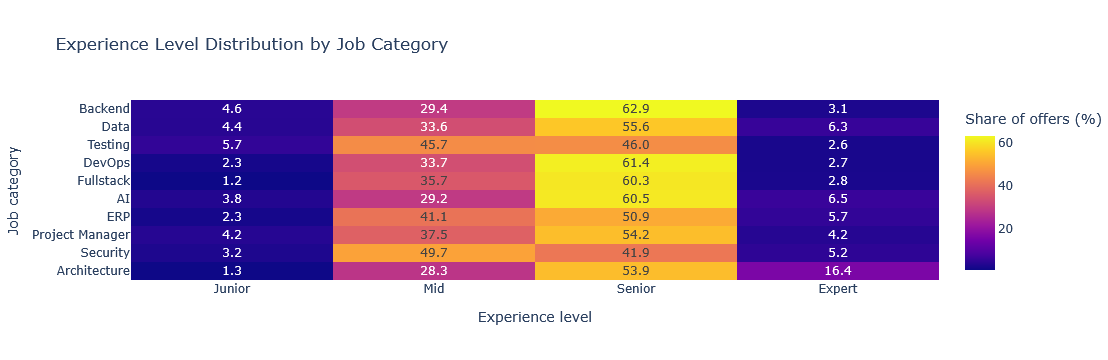

In [21]:
fig = px.imshow(
    category_experience,
    text_auto=".1f",
    aspect="auto",
    title="Experience Level Distribution by Job Category",
    labels={
        "x": "Experience level",
        "y": "Job category",
        "color": "Share of offers (%)"
    }
)

fig.show()

### Key observations

Backend is the largest category, with 625 offers, followed by Data with 430. Testing, DevOps and Fullstack each contain more than 250 offers.

Senior roles dominate Backend (62.9%), DevOps (61.4%), AI (60.5%) and Fullstack (60.3%). Testing is more balanced, with Mid and Senior roles representing 45.7% and 46.0% respectively.

Junior opportunities remain limited across every leading category. Their largest share among the Top 10 categories is 5.7% in Testing.

Architecture has the highest Expert share at 16.4%, while Data and AI also have comparatively high Expert representation at 6.3% and 6.5%.


## 5. Contract types

This section examines the distribution of employment contract types across job offers.

The initial analysis uses the original contract values, including offers that provide multiple contract options. Missing contract information is also included to show the completeness of the data.

In [22]:
df['contract_type'].unique()

array([nan, 'B2B', 'B2B, Umowa o pracę', 'Umowa o pracę',
       'B2B, Umowa zlecenie', 'Umowa zlecenie',
       'Umowa o pracę, Umowa zlecenie'], dtype=object)

In [23]:
contract_type_summary = (
    df["contract_type"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("contract_type")
    .reset_index(name="job_offers")
)

contract_type_summary["percentage"] = (
    contract_type_summary["job_offers"]
    / len(df)
    * 100
).round(1)

contract_type_summary

,contract_type,job_offers,percentage
0,B2B,2253,67.1
1,Missing,771,22.9
2,"B2B, Umowa o pracę",216,6.4
3,Umowa o pracę,116,3.5
4,Umowa zlecenie,2,0.1
5,"B2B, Umowa zlecenie",1,0.0
6,"Umowa o pracę, Umowa zlecenie",1,0.0


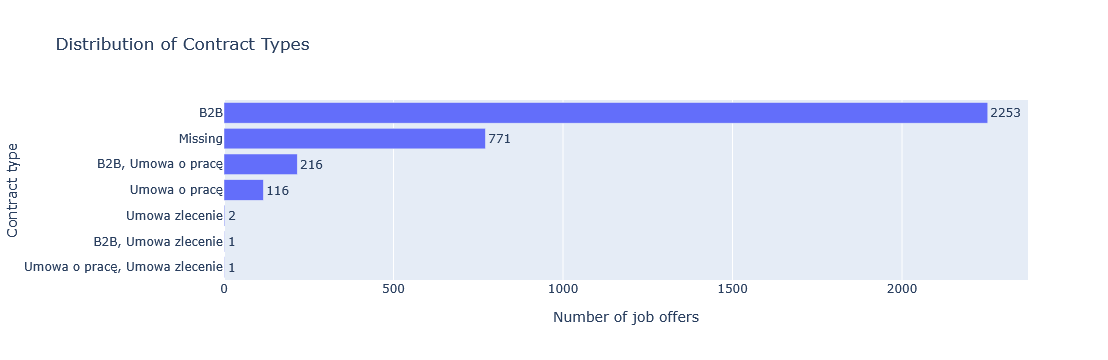

In [24]:
contract_type_plot = (
    contract_type_summary
    .sort_values(
        "job_offers",
        ascending=True
    )
)

fig = px.bar(
    contract_type_plot,
    x="job_offers",
    y="contract_type",
    orientation="h",
    text="job_offers",
    title="Distribution of Contract Types",
    labels={
        "job_offers": "Number of job offers",
        "contract_type": "Contract type"
    }
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    showlegend=False
)

fig.show()

In [25]:
experience_order = [
    "Junior",
    "Mid",
    "Senior",
    "Expert"
]

contract_experience = (
    pd.crosstab(
        df["experience"],
        df["contract_type"].fillna("Missing"),
        normalize="index"
    )
    * 100
).round(1)

contract_experience = (
    contract_experience
    .reindex(experience_order)
)

contract_experience

contract_type,B2B,"B2B, Umowa o pracę","B2B, Umowa zlecenie",Missing,Umowa o pracę,"Umowa o pracę, Umowa zlecenie",Umowa zlecenie
experience,,,,,,,
Junior,41.5,8.5,0.0,38.7,9.2,0.7,1.4
Mid,68.7,7.9,0.1,19.9,3.4,0.0,0.0
Senior,69.7,5.3,0.0,21.9,3.1,0.0,0.0
Expert,57.6,6.9,0.0,32.6,2.8,0.0,0.0


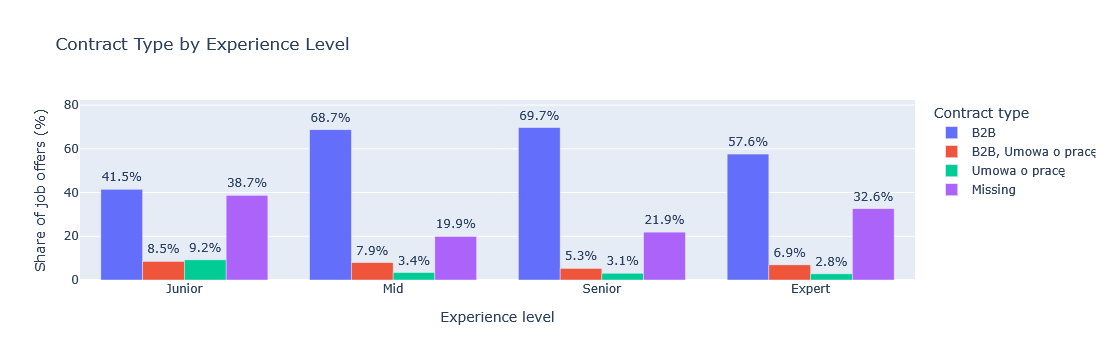

In [26]:
main_contract_types = [
    "B2B",
    "B2B, Umowa o pracę",
    "Umowa o pracę",
    "Missing"
]

contract_experience_plot = (
    contract_experience[
        main_contract_types
    ]
    .reset_index()
    .melt(
        id_vars="experience",
        var_name="contract_type",
        value_name="percentage"
    )
)

fig = px.bar(
    contract_experience_plot,
    x="experience",
    y="percentage",
    color="contract_type",
    barmode="group",
    text="percentage",
    category_orders={
        "experience": [
            "Junior",
            "Mid",
            "Senior",
            "Expert"
        ]
    },
    title="Contract Type by Experience Level",
    labels={
        "experience": "Experience level",
        "percentage": "Share of job offers (%)",
        "contract_type": "Contract type"
    }
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

fig.show()

### Key observations

B2B is the dominant reported contract type, appearing as the only option in 67.1% of all offers. A further 6.4% provide both B2B and an employment contract, while employment contracts alone account for 3.5%.

Contract information is missing for 22.9% of the dataset, so comparisons between employment arrangements should be interpreted cautiously.

B2B accounts for 69.7% of Senior and 68.7% of Mid-level offers, compared with 41.5% of Junior offers. Junior positions have the highest observed employment-contract share at 9.2%, but also the highest missing-contract share at 38.7%.

The available data therefore associates B2B most strongly with Mid and Senior recruitment, while Junior offers more frequently provide an employment contract or omit contract information.


## 6. Company Analysis

This section examines company-level recruitment activity, market concentration and differences between company-size segments.

### Company Data Quality

In [27]:
company_overview = pd.Series({
    "Job offers": len(df),
    "Company available": df["company"].notna().sum(),
    "Company missing": df["company"].isna().sum(),
    "Unique company names": df["company"].nunique(),
    "Company size available (%)": (
        df["company_size"].notna().mean() * 100
    ),
}).round(1)

company_overview

Job offers                    3360.0
Company available             3360.0
Company missing                  0.0
Unique company names           373.0
Company size available (%)      73.6
dtype: float64

In [28]:
df['company'].nunique()

373

In [29]:
company_mapping = {
    "Allegro sp. z o.o.": "Allegro",
    "DCG sp. z o.o.": "DCG",
    "Finture Sp. z o.o": "Finture",
    "Finture Sp. z o.o.": "Finture",
    "Iteamly": "iTeamly",
    "UNITY-T GROUP": "Unity-T Group",
    "Comscore (via CC)": "Comscore via CC"
}

df["company"] = df["company"].replace(company_mapping)

### Companies with the Highest Recruitment Activity

The ranking shows the number of unique offers published by each company. It represents job-posting activity on No Fluff Jobs rather than the total employment scale of an organization.

In [30]:
company_ranking = (
    df.dropna(subset=["company"])
    .groupby("company")
    .agg(
        job_offers=("job_id", "nunique")
    )
    .sort_values(
        "job_offers",
        ascending=False,
    )
)

company_ranking.head(10)

,job_offers
company,
Antal,210
Mindbox Sp. z o.o.,188
Scalo,178
Link Group,154
Upvanta,101
Square One Resources,99
GFT Poland,89
Ework Group,79
Belvedere Recruitment,78


In [31]:
top_10_companies = (
    company_ranking
    .head(10)
    .sort_values(
        "job_offers",
        ascending=True,
    )
    .reset_index()
)

top_10_companies

,company,job_offers
0,ITFS Sp. z o.o.,75
1,Belvedere Recruitment,78
2,Ework Group,79
3,GFT Poland,89
4,Square One Resources,99
5,Upvanta,101
6,Link Group,154
7,Scalo,178
8,Mindbox Sp. z o.o.,188
9,Antal,210


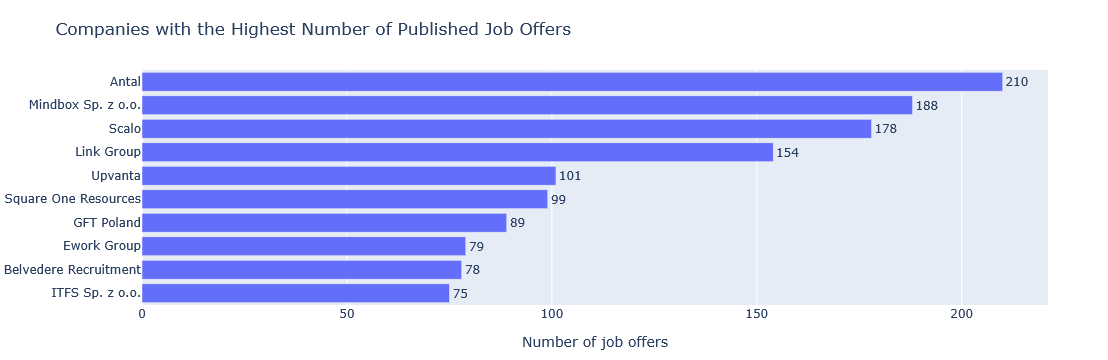

In [32]:

fig = px.bar(
    top_10_companies,
    x="job_offers",
    y="company",
    orientation="h",
    text="job_offers",
    title=(
        "Companies with the Highest Number "
        "of Published Job Offers"
    ),
    labels={
        "job_offers": "Number of job offers",
        "company": "Company",
    },
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    yaxis_title=None,
    showlegend=False,
    margin=dict(
        l=20,
        r=60,
        t=70,
        b=40,
    ),
)

fig.show()

In [33]:
company_offer_counts = (
    df.dropna(subset=["company"])
    .groupby("company")["job_id"]
    .nunique()
    .sort_values(ascending=False)
)

total_companies = company_offer_counts.size
total_offers_with_company = company_offer_counts.sum()

top_10_offers = company_offer_counts.head(10).sum()
top_20_offers = company_offer_counts.head(20).sum()

top_10_share = (
    top_10_offers
    / total_offers_with_company
    * 100
)

top_20_share = (
    top_20_offers
    / total_offers_with_company
    * 100
)

single_offer_companies = (
    company_offer_counts == 1
).sum()

single_offer_company_share = (
    single_offer_companies
    / total_companies
    * 100
)

median_offers_per_company = (
    company_offer_counts.median()
)

In [34]:
market_concentration = pd.DataFrame({
    "metric": [
        "Companies",
        "Offers with identified company",
        "Offers from Top 10 companies",
        "Offers from Top 10 companies (%)",
        "Offers from Top 20 companies",
        "Offers from Top 20 companies (%)",
        "Companies with one offer",
        "Companies with one offer (%)",
        "Median offers per company",
    ],
    "value": [
        total_companies,
        total_offers_with_company,
        top_10_offers,
        round(top_10_share, 1),
        top_20_offers,
        round(top_20_share, 1),
        single_offer_companies,
        round(single_offer_company_share, 1),
        median_offers_per_company,
    ],
})

market_concentration

,metric,value
0,Companies,368.0
1,Offers with identified company,3360.0
2,Offers from Top 10 companies,1251.0
3,Offers from Top 10 companies (%),37.2
4,Offers from Top 20 companies,1864.0
5,Offers from Top 20 companies (%),55.5
6,Companies with one offer,150.0
7,Companies with one offer (%),40.8
8,Median offers per company,2.0


### Key observation

Job-posting activity is concentrated among a relatively small group of organizations. The 10 most active companies account for 37.2% of offers and the Top 20 account for 55.5%.

At the same time, 40.8% of companies published only one offer, and the median company published two. This indicates a long-tail distribution in which a small group of highly active recruiters generates a substantial share of listings.

These figures describe activity observed on No Fluff Jobs and should not be interpreted as formal employer market shares.


### Company Size Distribution

This section examines which company-size segments publish the most job offers. Company-size segments are based on the reported lower employee-count boundary.

In [35]:
company_size_order = [
    "Small",
    "Medium",
    "Large",
    "Enterprise",
    "Missing",
]

company_size_summary = (
    df["company_size_segment"]
    .value_counts()
    .reindex(
        company_size_order,
        fill_value=0,
    )
    .rename_axis("company_size_segment")
    .reset_index(name="job_offers")
)

company_size_summary["percentage"] = (
    company_size_summary["job_offers"]
    / len(df)
    * 100
).round(1)

company_size_summary

,company_size_segment,job_offers,percentage
0,Small,181,5.4
1,Medium,544,16.2
2,Large,929,27.6
3,Enterprise,820,24.4
4,Missing,886,26.4


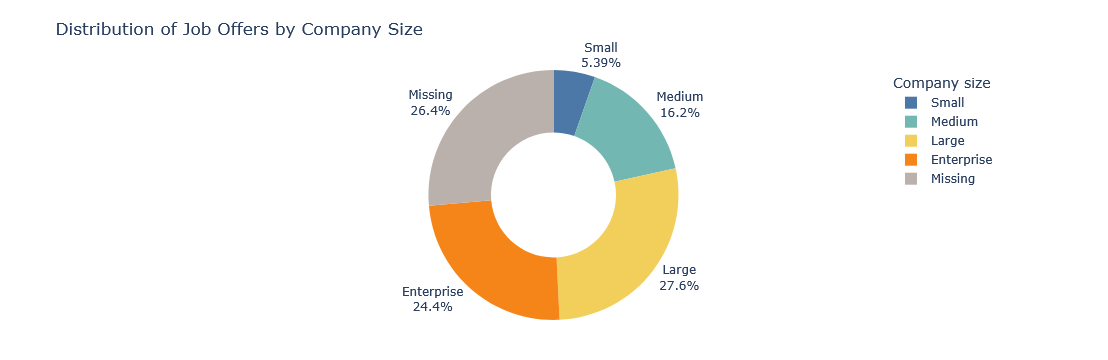

In [36]:
company_size_colors = {
    "Small": "#4C78A8",
    "Medium": "#72B7B2",
    "Large": "#F2CF5B",
    "Enterprise": "#F58518",
    "Missing": "#BAB0AC",
}

fig = px.pie(
    company_size_summary,
    names="company_size_segment",
    values="job_offers",
    hole=0.5,
    title="Distribution of Job Offers by Company Size",
    color="company_size_segment",
    color_discrete_map=company_size_colors,
    category_orders={
        "company_size_segment": company_size_order,
    },
)

fig.update_traces(
    textinfo="percent+label",
    textposition="outside",
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Job offers: %{value}<br>"
        "Share: %{percent}"
        "<extra></extra>"
    ),
)

fig.update_layout(
    showlegend=True,
    legend_title_text="Company size",
    margin=dict(
        l=40,
        r=40,
        t=70,
        b=40,
    ),
)

fig.show()

In [37]:
company_size_order = [
    "Small",
    "Medium",
    "Large",
    "Enterprise",
]

### Company Size by Experience Level

This section compares the experience-level distribution within each company-size segment.

> Are smaller companies more likely to hire experienced candidates than larger organizations?

In [38]:
experience_order = [
    "Junior",
    "Mid",
    "Senior",
    "Expert",
    "Missing",
]

company_experience_df = (
    df.loc[
        df["company_size_segment"].isin(
            company_size_order
        )
    ]
    .assign(
        experience=lambda data:
            data["experience"].fillna("Missing")
    )
)

In [39]:
company_experience = (
    pd.crosstab(
        company_experience_df["company_size_segment"],
        company_experience_df["experience"],
        normalize="index",
    )
    .mul(100)
    .round(1)
    .reindex(
        index=company_size_order,
        columns=experience_order,
        fill_value=0,
    )
)

company_experience

experience,Junior,Mid,Senior,Expert,Missing
company_size_segment,,,,,
Small,6.1,26.5,63.5,3.3,0.6
Medium,2.6,51.5,43.4,2.6,0.0
Large,1.7,37.0,57.2,3.7,0.4
Enterprise,6.8,30.4,54.9,6.1,1.8


In [40]:
company_experience_plot = (
    company_experience
    .reset_index()
    .melt(
        id_vars="company_size_segment",
        var_name="experience",
        value_name="percentage",
    )
)

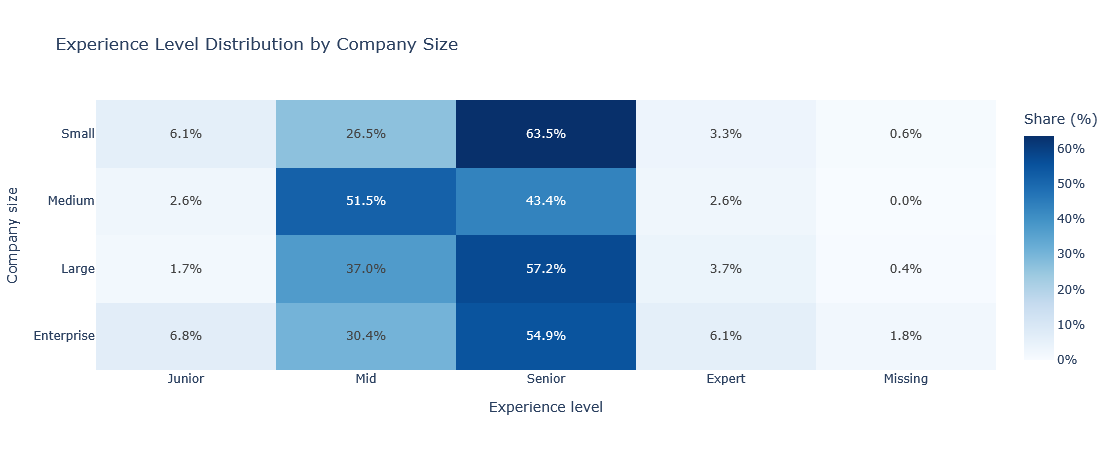

In [41]:
fig = px.imshow(
    company_experience,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Blues",
    title="Experience Level Distribution by Company Size",
    labels={
        "x": "Experience level",
        "y": "Company size",
        "color": "Share of offers (%)",
    },
)

fig.update_traces(
    texttemplate="%{z:.1f}%",
    hovertemplate=(
        "Company size: %{y}<br>"
        "Experience: %{x}<br>"
        "Share: %{z:.1f}%"
        "<extra></extra>"
    ),
)

fig.update_layout(
    height=450,
    xaxis_side="bottom",
    coloraxis_colorbar=dict(
        title="Share (%)",
        ticksuffix="%",
    ),
)

fig.show()

### Company Size by Workplace Model

This section examines how remote, hybrid and onsite work arrangements differ across company-size segments.

> Which company sizes offer the greatest workplace flexibility?

In [42]:
workplace_order = [
    "Remote",
    "Hybrid",
    "Onsite",
    "Missing",
]

company_workplace_df = (
    df.loc[
        df["company_size_segment"].isin(
            company_size_order
        )
    ]
    .assign(
        workplace=lambda data:
            data["workplace"].fillna("Missing")
    )
)

In [43]:
company_workplace = (
    pd.crosstab(
        company_workplace_df["company_size_segment"],
        company_workplace_df["workplace"],
        normalize="index",
    )
    .mul(100)
    .round(1)
    .reindex(
        index=company_size_order,
        columns=workplace_order,
        fill_value=0,
    )
)

company_workplace

workplace,Remote,Hybrid,Onsite,Missing
company_size_segment,,,,
Small,66.9,25.4,0.6,7.2
Medium,42.5,41.4,0.2,16.0
Large,39.8,53.3,0.0,6.9
Enterprise,18.2,75.0,0.0,6.8


In [44]:
company_workplace_plot = (
    company_workplace
    .reset_index()
    .melt(
        id_vars="company_size_segment",
        var_name="workplace",
        value_name="percentage",
    )
)

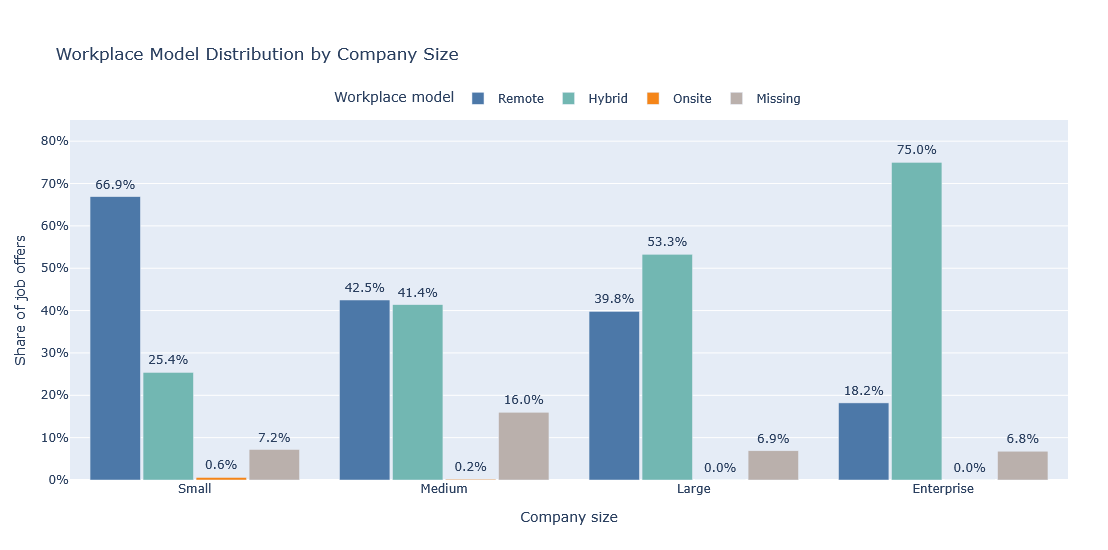

In [45]:
workplace_order = [
    "Remote",
    "Hybrid",
    "Onsite",
    "Missing",
]

workplace_colors = {
    "Remote": "#4C78A8",
    "Hybrid": "#72B7B2",
    "Onsite": "#F58518",
    "Missing": "#BAB0AC",
}

company_workplace_plot["label"] = (
    company_workplace_plot["percentage"]
    .apply(lambda value: f"{value:.1f}%")
)

fig = px.bar(
    company_workplace_plot,
    x="company_size_segment",
    y="percentage",
    color="workplace",
    text="label",
    barmode="group",
    category_orders={
        "company_size_segment": company_size_order,
        "workplace": workplace_order,
    },
    color_discrete_map=workplace_colors,
    title="Workplace Model Distribution by Company Size",
    labels={
        "company_size_segment": "Company size",
        "percentage": "Share of job offers (%)",
        "workplace": "Workplace model",
    },
)

fig.update_traces(
    texttemplate="%{text}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Company size: %{x}<br>"
        "Share: %{y:.1f}%"
        "<extra></extra>"
    ),
)

fig.update_layout(
    width=1050,
    height=550,
    bargap=0.15,
    bargroupgap=0.05,
    yaxis=dict(
        title="Share of job offers",
        ticksuffix="%",
        range=[
            0,
            company_workplace_plot["percentage"].max() + 10,
        ],
    ),
    xaxis=dict(
        title="Company size",
        categoryorder="array",
        categoryarray=company_size_order,
    ),
    legend=dict(
        title="Workplace model",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
    ),
    uniformtext_minsize=8,
    uniformtext_mode="show",
    margin=dict(
        l=70,
        r=40,
        t=120,
        b=70,
    ),
)

fig.show()

### Company Size by Contract Type

This section compares the most common contract options across company-size segments. Contract combinations are preserved because a single job offer may provide more than one employment option.

In [46]:
main_contract_mapping = {
    "B2B": "B2B",
    "Umowa o pracę": "UoP",
    "B2B, Umowa o pracę": "B2B + UoP",
}

df["contract_group"] = (
    df["contract_type"]
    .map(main_contract_mapping)
)

df["contract_group"] = (
    df["contract_group"]
    .where(
        df["contract_type"].isna()
        | df["contract_group"].notna(),
        "Other",
    )
    .fillna("Missing")
)

In [47]:
contract_order = [
    "B2B",
    "UoP",
    "B2B + UoP",
    "Other",
    "Missing",
]

In [48]:
company_contract_df = (
    df.loc[
        df["company_size_segment"].isin(
            company_size_order
        )
    ]
)

company_contract = (
    pd.crosstab(
        company_contract_df["company_size_segment"],
        company_contract_df["contract_group"],
        normalize="index",
    )
    .mul(100)
    .round(1)
    .reindex(
        index=company_size_order,
        columns=contract_order,
        fill_value=0,
    )
)

company_contract

contract_group,B2B,UoP,B2B + UoP,Other,Missing
company_size_segment,,,,,
Small,83.4,1.1,2.2,0.0,13.3
Medium,79.6,2.6,2.4,0.2,15.3
Large,84.3,3.7,0.4,0.0,11.6
Enterprise,43.9,4.1,0.6,0.1,51.2


In [49]:
company_contract_plot = (
    company_contract
    .reset_index()
    .melt(
        id_vars="company_size_segment",
        var_name="contract_group",
        value_name="percentage",
    )
)

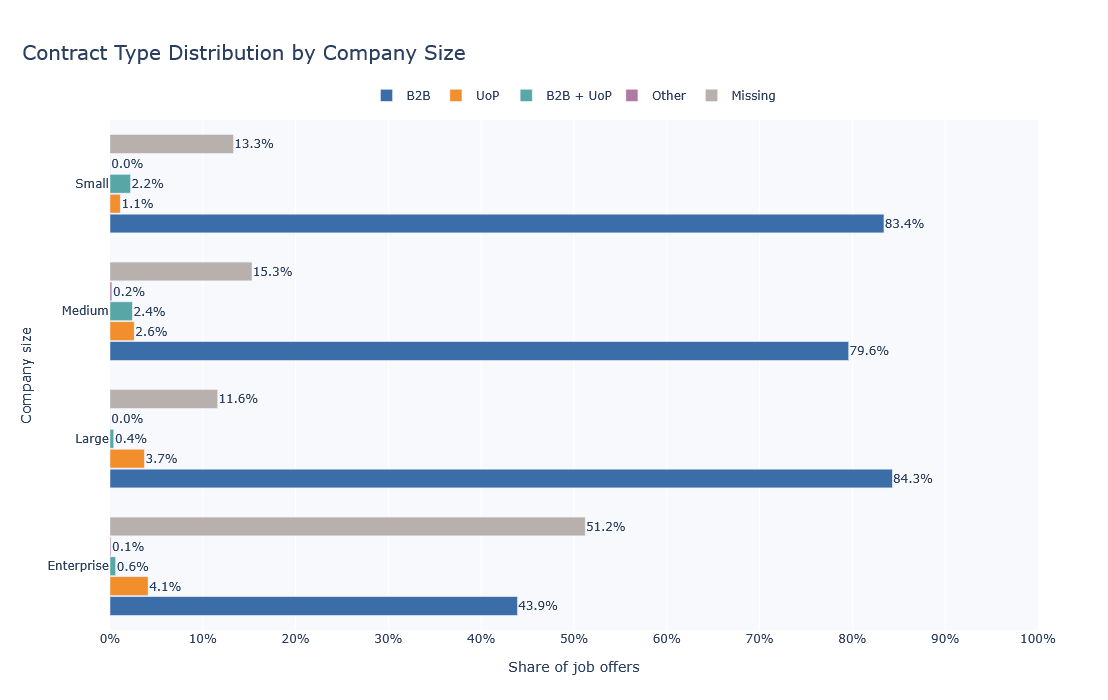

In [50]:
contract_order = [
    "B2B",
    "UoP",
    "B2B + UoP",
    "Other",
    "Missing",
]

contract_colors = {
    "B2B": "#3B6EA8",
    "UoP": "#F28E2B",
    "B2B + UoP": "#59A6A6",
    "Other": "#AF7AA1",
    "Missing": "#B8B0AD",
}

company_contract_plot["label"] = (
    company_contract_plot["percentage"]
    .apply(lambda value: f"{value:.1f}%")
)

fig = px.bar(
    company_contract_plot,
    x="percentage",
    y="company_size_segment",
    color="contract_group",
    text="label",
    orientation="h",
    barmode="group",
    category_orders={
        "company_size_segment": company_size_order,
        "contract_group": contract_order,
    },
    color_discrete_map=contract_colors,
    title="Contract Type Distribution by Company Size",
    labels={
        "company_size_segment": "Company size",
        "percentage": "Share of job offers (%)",
        "contract_group": "Contract type",
    },
)

fig.update_traces(
    texttemplate="%{text}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Company size: %{y}<br>"
        "Share of offers: %{x:.1f}%"
        "<extra></extra>"
    ),
)

fig.update_layout(
    width=1200,
    height=700,
    bargap=0.22,
    bargroupgap=0.06,
    plot_bgcolor="#F7F9FC",
    paper_bgcolor="white",
    title=dict(
        x=0.02,
        xanchor="left",
        font=dict(size=20),
    ),
    xaxis=dict(
        title="Share of job offers",
        range=[0, 100],
        tickmode="linear",
        tick0=0,
        dtick=10,
        ticksuffix="%",
        gridcolor="white",
        zeroline=False,
    ),
    yaxis=dict(
        title="Company size",
        categoryorder="array",
        categoryarray=list(
            reversed(company_size_order)
        ),
    ),
    legend=dict(
        title=None,
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
    ),
    uniformtext_minsize=8,
    uniformtext_mode="show",
    margin=dict(
        l=110,
        r=70,
        t=120,
        b=70,
    ),
)

fig.show()

### Key observations

Large companies publish 27.6% of all offers and Enterprise organizations 24.4%. Medium and Small companies account for 16.2% and 5.4%, while company size is unavailable for 26.4% of offers.

Small companies have the strongest Senior concentration at 63.9%. Medium companies differ from the remaining segments because Mid-level roles form their largest group at 51.5%.

Junior roles remain limited across all known company sizes. Their share ranges from 1.7% in Large companies to 7.0% in Enterprise organizations.

Remote work is most common among Small companies at 66.9%. Its share falls to 18.2% among Enterprise organizations, where Hybrid work accounts for 75.0% of offers.

B2B dominates Small, Medium and Large companies. Enterprise companies show a much lower observed B2B share of 43.9%, but contract information is missing for 51.2% of their offers, preventing a strong conclusion.


### Profile of the Most Active Companies

This table summarizes the recruitment profiles of the ten companies with the highest number of published job offers.

In [51]:
def most_common_value(series):
    values = series.dropna()

    if values.empty:
        return "Missing"

    return values.mode().iloc[0]

In [52]:
top_company_names = (
    df.dropna(subset=["company"])
    .groupby("company")["job_id"]
    .nunique()
    .nlargest(10)
    .index
)

In [53]:
top_company_profiles = (
    df[df["company"].isin(top_company_names)]
    .groupby("company")
    .agg(
        job_offers=("job_id", "nunique"),
        dominant_category=(
            "category",
            most_common_value,
        ),
        dominant_experience=(
            "experience",
            most_common_value,
        ),
        dominant_workplace=(
            "workplace",
            most_common_value,
        ),
        dominant_company_size=(
            "company_size_segment",
            most_common_value,
        ),
    )
    .sort_values(
        "job_offers",
        ascending=False,
    )
    .reset_index()
)

top_company_profiles

,company,job_offers,dominant_category,dominant_experience,dominant_workplace,dominant_company_size
0,Antal,210,Data,Mid,Hybrid,Medium
1,Mindbox Sp. z o.o.,188,Backend,Senior,Hybrid,Missing
2,Scalo,178,Data,Senior,Hybrid,Large
3,Link Group,154,Backend,Senior,Remote,Large
4,Upvanta,101,Backend,Mid,Remote,Missing
5,Square One Resources,99,Data,Senior,Remote,Small
6,GFT Poland,89,Data,Senior,Hybrid,Enterprise
7,Ework Group,79,Data,Senior,Hybrid,Large
8,Belvedere Recruitment,78,Backend,Senior,Hybrid,Missing
9,ITFS Sp. z o.o.,75,Testing,Mid,Remote,Large


### Key observations

Antal has the highest observed recruitment activity with 210 offers, followed by Mindbox with 188, Scalo with 178 and Link Group with 154.

Recruitment, consulting and outsourcing organizations dominate the ranking. Their offers may represent multiple clients, so high activity does not necessarily indicate internal company growth.

Senior positions dominate six of the ten most active companies. Antal, Upvanta and ITFS most frequently target Mid-level candidates.

Hybrid work dominates Antal, Mindbox, Scalo, GFT, Ework Group and Belvedere Recruitment. Link Group, Upvanta, Square One Resources and ITFS publish predominantly Remote roles.

Backend and Data are the most common dominant categories among the leading companies. These results describe recruitment activity visible on No Fluff Jobs rather than total organizational hiring.


## 7. Salary analysis

This section compares standardized monthly salary ranges in PLN. Medians and quartiles are preferred because salary distributions are right-skewed.


### 7.1 Analysis scope and salary distribution

Begin with all records that can be normalized by currency and salary period, then apply a plausibility filter only within the salary analysis.


In [54]:
salary_df = df.loc[
    df["salary_analysis_eligible"]
].copy()

print("All offers:", len(df))
print("Eligible salary offers:", len(salary_df))

salary_df[
    [
        "salary_min_pln_monthly",
        "salary_max_pln_monthly",
        "salary_mid_pln_monthly",
    ]
].describe().round(2)

All offers: 3360
Eligible salary offers: 2352


,salary_min_pln_monthly,salary_max_pln_monthly,salary_mid_pln_monthly
count,2352.00,2352.00,2352.00
mean,21975.64,27176.42,24576.03
std,6976.27,8356.08,7510.16
min,90.00,110.00,100.00
25%,17994.00,22000.00,20160.00
50%,21840.00,26880.00,24360.00
75%,26250.00,31920.00,29030.00
max,63000.00,100800.00,81900.00


In [55]:
salary_df = df.loc[
    df["salary_analysis_eligible"]
    & df["salary_mid_pln_monthly"].between(
        5000,
        100000,
    )
].copy()

print("Eligible before quality filter:", df["salary_analysis_eligible"].sum())
print("Included after quality filter:", len(salary_df))
print(
    "Excluded as implausible:",
    df["salary_analysis_eligible"].sum() - len(salary_df),
)

Eligible before quality filter: 2352
Included after quality filter: 2339
Excluded as implausible: 13


### Salary analysis scope

Salary records were standardized to approximate monthly PLN values.
Offers with a midpoint below PLN 5,000 or above PLN 100,000 were excluded
from salary comparisons as implausible source-data values.

The records remain in the cleaned dataset and are excluded only from
salary-related analysis.

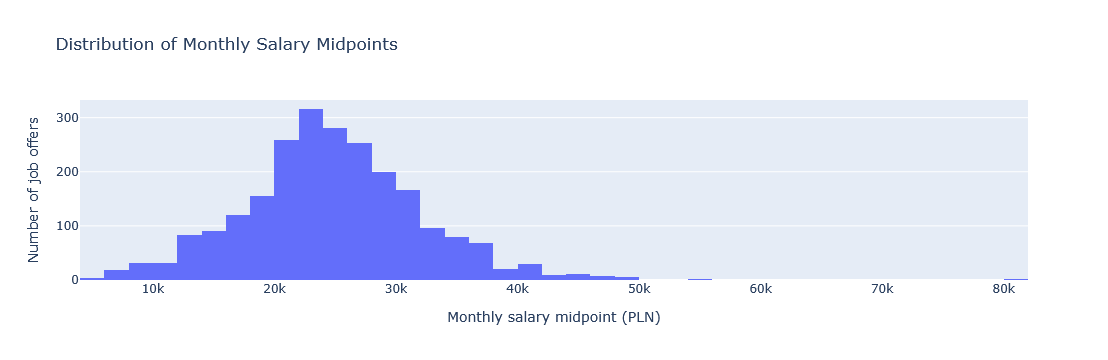

In [56]:
fig = px.histogram(
    salary_df,
    x="salary_mid_pln_monthly",
    nbins=40,
    title="Distribution of Monthly Salary Midpoints",
    labels={
        "salary_mid_pln_monthly":
            "Monthly salary midpoint (PLN)"
    },
)

fig.update_layout(
    yaxis_title="Number of job offers",
    showlegend=False,
)

fig.show()

### Key observations

- The median monthly salary midpoint is approximately PLN 24,360.
- Half of the analyzed offers fall between approximately PLN 20,160
  and PLN 29,030.
- The mean is slightly higher than the median, indicating a
  right-skewed salary distribution.
- A relatively small number of highly paid offers extends the upper
  tail of the distribution.
- Salary comparisons should therefore primarily use medians rather
  than means, because medians are less affected by extreme values.

### 7.2 Salary by experience level

Compare medians and the middle 50% of salary ranges across standardized experience levels.


In [57]:
salary_by_experience = (
    salary_df
    .dropna(subset=["experience"])
    .groupby(
        "experience",
        observed=True,
    )
    .agg(
        job_offers=("job_id", "nunique"),
        median_salary=("salary_mid_pln_monthly", "median"),
        q1_salary=("salary_mid_pln_monthly", lambda x: x.quantile(0.25)),
        q3_salary=("salary_mid_pln_monthly", lambda x: x.quantile(0.75)),
    )
    .round(0)
    .reset_index()
)

experience_order = [
    "Junior",
    "Mid",
    "Senior",
    "Expert",
]

salary_by_experience["experience"] = pd.Categorical(
    salary_by_experience["experience"],
    categories=experience_order,
    ordered=True,
)

salary_by_experience = (
    salary_by_experience
    .sort_values("experience")
)


In [58]:
junior_median = (
    salary_by_experience
    .loc[
        salary_by_experience["experience"] == "Junior",
        "median_salary",
    ]
    .iloc[0]
)

salary_by_experience["salary_premium_vs_junior_pct"] = (
    (
        salary_by_experience["median_salary"]
        / junior_median
        - 1
    )
    * 100
).round(1)

salary_by_experience

,experience,job_offers,median_salary,q1_salary,q3_salary,salary_premium_vs_junior_pct
1,Junior,90,13225.0,8719.0,19194.0,0.0
2,Mid,798,21000.0,17000.0,26040.0,58.8
3,Senior,1352,25620.0,22680.0,29846.0,93.7
0,Expert,99,30240.0,27150.0,33600.0,128.7


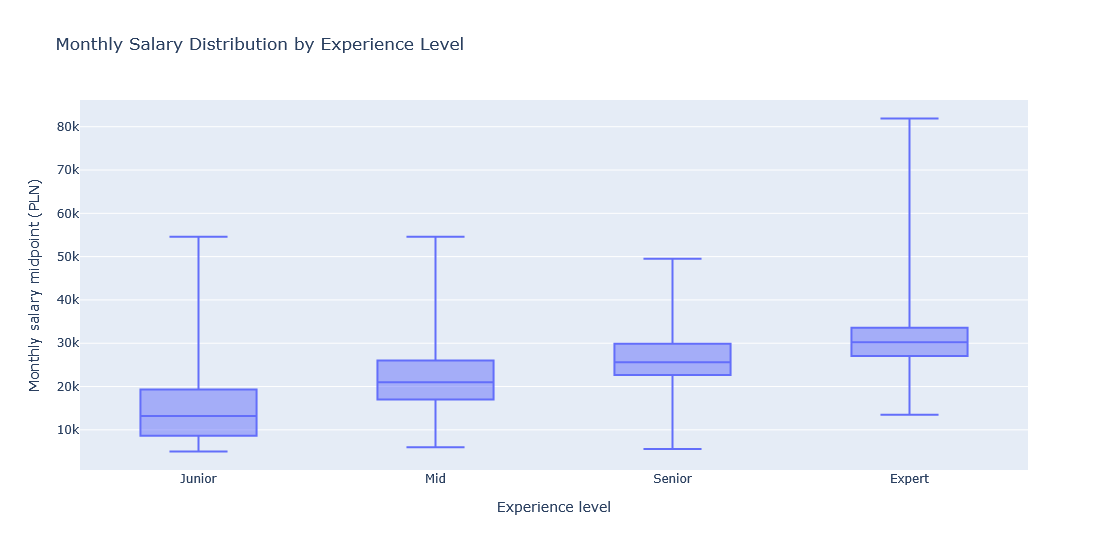

In [59]:
fig = px.box(
    salary_df.dropna(subset=["experience"]),
    x="experience",
    y="salary_mid_pln_monthly",
    category_orders={
        "experience": experience_order,
    },
    points=False,
    title="Monthly Salary Distribution by Experience Level",
    labels={
        "experience": "Experience level",
        "salary_mid_pln_monthly":
            "Monthly salary midpoint (PLN)",
    },
)

fig.update_layout(
    showlegend=False,
    height=550,
)

fig.show()

### Key observations

- Median salary increases consistently with experience, from PLN 13,225
  for Junior roles to PLN 30,240 for Expert positions.
- Mid-level roles offer a median salary of PLN 21,000, approximately
  58.8% more than Junior positions.
- The Senior median reaches PLN 25,620, representing a 93.7% premium
  over Junior roles.
- Expert positions have the highest median salary, approximately 128.7%
  above the Junior median.
- The middle 50% of salaries also shifts upward across experience levels,
  confirming that the relationship is visible across the distributions,
  not only in their median values.
- Junior and Expert results should be interpreted more cautiously because
  they are based on 90 and 99 offers respectively, compared with 798 Mid
  and 1,352 Senior offers.

### 7.3 Salary by job category

Compare categories with at least 30 salary observations, then repeat the comparison for Senior roles to partially control for experience composition.


In [60]:
salary_by_category = (
    salary_df
    .dropna(subset=["category"])
    .groupby("category")
    .agg(
        job_offers=("job_id", "nunique"),
        median_salary=("salary_mid_pln_monthly", "median"),
        q1_salary=("salary_mid_pln_monthly", lambda x: x.quantile(0.25)),
        q3_salary=("salary_mid_pln_monthly", lambda x: x.quantile(0.75)),
    )
    .reset_index()
)

salary_by_category = (
    salary_by_category
    .query("job_offers >= 30")
    .sort_values("median_salary")
)

salary_by_category[
    [
        "median_salary",
        "q1_salary",
        "q3_salary",
    ]
] = salary_by_category[
    [
        "median_salary",
        "q1_salary",
        "q3_salary",
    ]
].round(0)

salary_by_category

,category,job_offers,median_salary,q1_salary,q3_salary
30,Testing,204,19320.0,15960.0,23520.0
27,Support,52,19320.0,12000.0,24327.0
5,Business Analysis,52,21210.0,17626.0,25200.0
14,Frontend,48,22275.0,20160.0,26888.0
21,Mobile,33,23100.0,17712.0,26000.0
24,Project Manager,116,23520.0,20475.0,27555.0
7,Data,332,24588.0,21755.0,28560.0
0,AI,126,24780.0,21840.0,29850.0
4,Backend,479,24780.0,21000.0,29500.0
18,Inne IT,30,25173.0,21525.0,29400.0


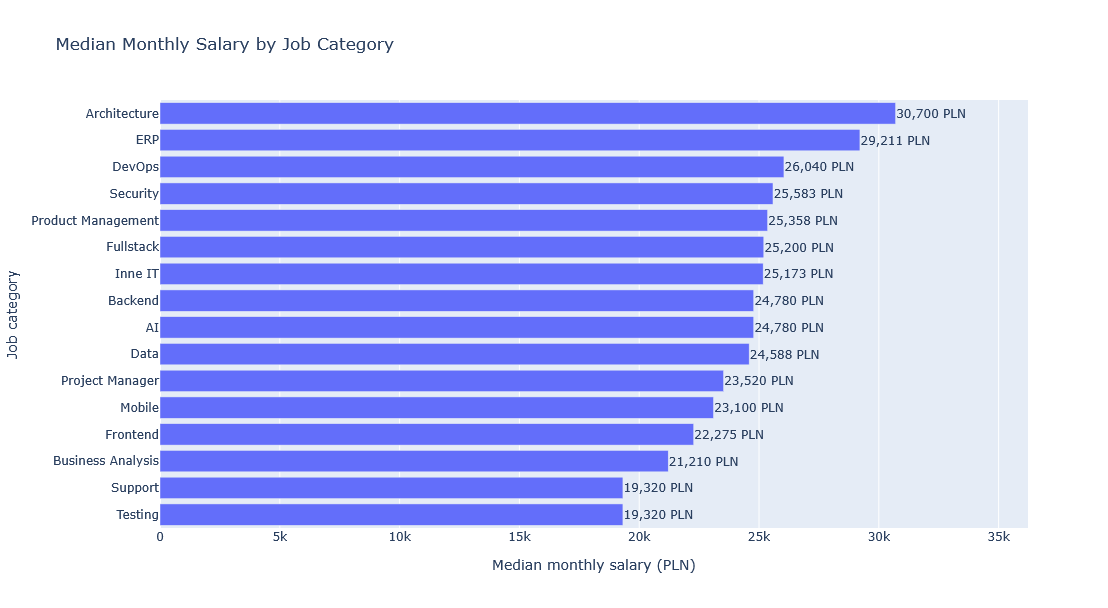

In [61]:
fig = px.bar(
    salary_by_category,
    x="median_salary",
    y="category",
    orientation="h",
    text="median_salary",
    title="Median Monthly Salary by Job Category",
    labels={
        "median_salary": "Median monthly salary (PLN)",
        "category": "Job category",
    },
)

fig.update_traces(
    texttemplate="%{text:,.0f} PLN",
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    showlegend=False,
    height=max(
        500,
        len(salary_by_category) * 38,
    ),
    xaxis_range=[
        0,
        salary_by_category["median_salary"].max() * 1.18,
    ],
)

fig.show()

In [62]:
senior_salary_by_category = (
    salary_df.loc[
        salary_df["experience"].eq("Senior")
    ]
    .dropna(subset=["category"])
    .groupby("category")
    .agg(
        job_offers=("job_id", "nunique"),
        median_salary=(
            "salary_mid_pln_monthly",
            "median",
        ),
    )
    .reset_index()
    .query("job_offers >= 20")
    .sort_values("median_salary")
)

senior_salary_by_category["median_salary"] = (
    senior_salary_by_category["median_salary"]
    .round(0)
)

senior_salary_by_category

,category,job_offers,median_salary
26,Testing,101,21840.0
5,Business Analysis,27,22680.0
13,Frontend,27,24360.0
20,Project Manager,68,25100.0
7,Data,199,25500.0
19,Product Management,31,26040.0
4,Backend,302,26040.0
14,Fullstack,115,26053.0
0,AI,80,26460.0
21,Security,49,26500.0


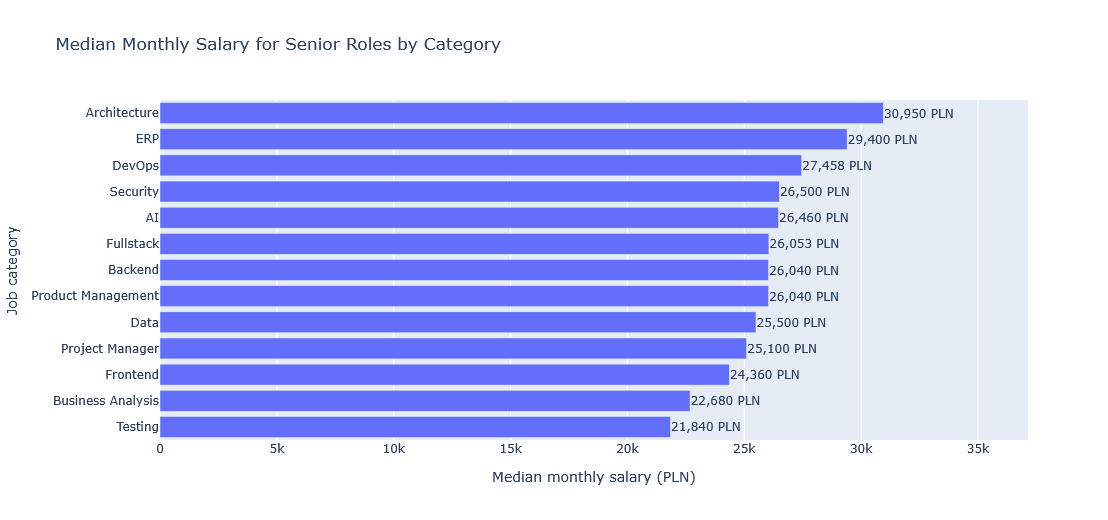

In [63]:
fig = px.bar(
    senior_salary_by_category,
    x="median_salary",
    y="category",
    orientation="h",
    text="median_salary",
    title="Median Monthly Salary for Senior Roles by Category",
    labels={
        "median_salary": "Median monthly salary (PLN)",
        "category": "Job category",
    },
)

fig.update_traces(
    texttemplate="%{text:,.0f} PLN",
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    showlegend=False,
    height=max(
        500,
        len(senior_salary_by_category) * 40,
    ),
    xaxis_range=[
        0,
        senior_salary_by_category["median_salary"].max() * 1.2,
    ],
)

fig.show()

### Key observations

- Architecture has the highest overall median among sufficiently represented categories at PLN 30,700, followed by ERP at PLN 29,211.
- Testing and Support have the lowest medians at PLN 19,320.
- After restricting the comparison to Senior roles, Architecture and ERP remain the highest-paying categories, suggesting that their position is not explained only by experience composition.
- Category rankings remain descriptive because specializations, contracts and employer profiles also differ between categories.


### 7.4 Salary by contract type

Compare the three principal reported contract groups. Rare and missing contract types remain in the dataset but are excluded from this chart.


In [64]:
def simplify_contract_type(value):
    if pd.isna(value):
        return "Missing"

    contracts = {
        item.strip()
        for item in str(value).split(",")
    }

    if {
        "B2B",
        "Umowa o pracę",
    }.issubset(contracts):
        return "B2B + UoP"

    if "B2B" in contracts:
        return "B2B"

    if "Umowa o pracę" in contracts:
        return "UoP"

    return "Other"


salary_df["contract_group"] = (
    salary_df["contract_type"]
    .apply(simplify_contract_type)
)

In [65]:
main_contracts = [
    "UoP",
    "B2B + UoP",
    "B2B",
]

contract_salary_plot = salary_df.loc[
    salary_df["contract_group"].isin(main_contracts)
].copy()

In [66]:
salary_by_contract = (
    contract_salary_plot
    .groupby("contract_group")
    .agg(
        job_offers=("job_id", "nunique"),
        median_salary=("salary_mid_pln_monthly", "median"),
        q1_salary=("salary_mid_pln_monthly", lambda x: x.quantile(0.25)),
        q3_salary=("salary_mid_pln_monthly", lambda x: x.quantile(0.75)),
    )
    .round(0)
    .reset_index()
)

salary_by_contract

,contract_group,job_offers,median_salary,q1_salary,q3_salary
0,B2B,1700,24360.0,20580.0,28560.0
1,B2B + UoP,194,28350.0,25200.0,32550.0
2,UoP,79,24311.0,17712.0,33788.0


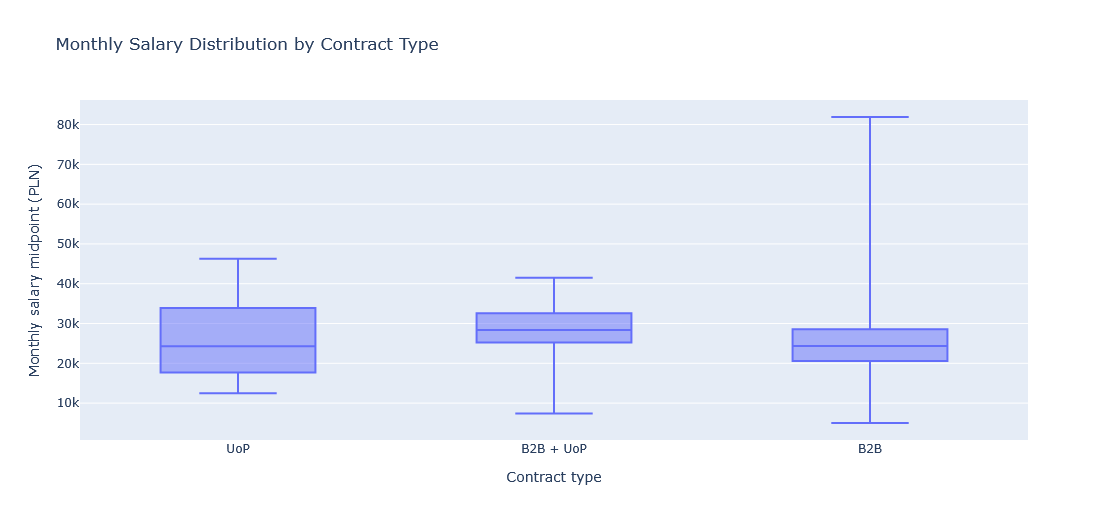

In [67]:
fig = px.box(
    contract_salary_plot,
    x="contract_group",
    y="salary_mid_pln_monthly",
    category_orders={
        "contract_group": main_contracts,
    },
    points=False,
    title="Monthly Salary Distribution by Contract Type",
    labels={
        "contract_group": "Contract type",
        "salary_mid_pln_monthly":
            "Monthly salary midpoint (PLN)",
    },
)

fig.update_layout(
    showlegend=False,
    height=520,
)

fig.show()

### Key observations

- Offers providing both B2B and UoP options have the highest median at PLN 28,350.
- B2B and UoP have similar medians of PLN 24,360 and PLN 24,311, although UoP has a wider middle salary range.
- Advertised B2B and UoP amounts are not directly equivalent because taxation, benefits and employer costs differ.


### 7.5 Salary by workplace model

Compare workplace groups with at least 30 salary observations and repeat the analysis for Senior roles.


In [68]:
workplace_counts = (
    salary_df["workplace"]
    .value_counts()
)

valid_workplaces = workplace_counts[
    workplace_counts >= 30
].index

workplace_salary_df = salary_df.loc[
    salary_df["workplace"].isin(valid_workplaces)
].copy()

In [69]:
salary_by_workplace = (
    workplace_salary_df
    .groupby("workplace")
    .agg(
        job_offers=("job_id", "nunique"),
        median_salary=("salary_mid_pln_monthly", "median"),
        q1_salary=("salary_mid_pln_monthly", lambda x: x.quantile(0.25)),
        q3_salary=("salary_mid_pln_monthly", lambda x: x.quantile(0.75)),
    )
    .round(0)
    .reset_index()
    .sort_values("median_salary")
)

salary_by_workplace

,workplace,job_offers,median_salary,q1_salary,q3_salary
0,Hybrid,1235,24360.0,20160.0,29400.0
1,Remote,954,24823.0,21000.0,28560.0


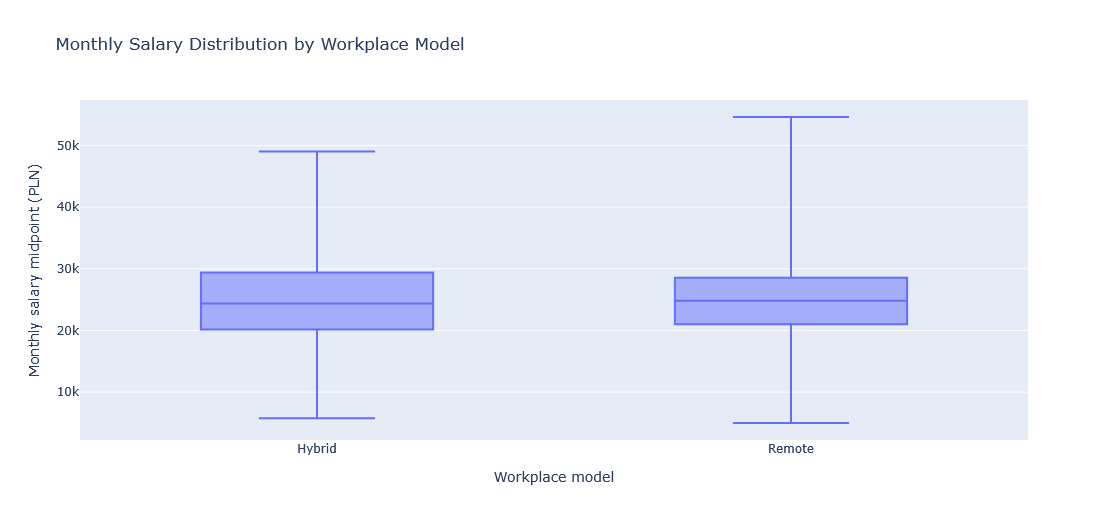

In [70]:
workplace_order = [
    workplace
    for workplace in ["Onsite", "Hybrid", "Remote"]
    if workplace in valid_workplaces
]

fig = px.box(
    workplace_salary_df,
    x="workplace",
    y="salary_mid_pln_monthly",
    category_orders={
        "workplace": workplace_order,
    },
    points=False,
    title="Monthly Salary Distribution by Workplace Model",
    labels={
        "workplace": "Workplace model",
        "salary_mid_pln_monthly":
            "Monthly salary midpoint (PLN)",
    },
)

fig.update_layout(
    showlegend=False,
    height=520,
)

fig.show()

In [71]:
senior_workplace_salary = (
    salary_df.loc[
        salary_df["experience"].eq("Senior")
        & salary_df["workplace"].isin(
            ["Remote", "Hybrid", "Onsite"]
        )
    ]
    .copy()
)

In [72]:
senior_workplace_counts = (
    senior_workplace_salary["workplace"]
    .value_counts()
)

valid_senior_workplaces = (
    senior_workplace_counts[
        senior_workplace_counts >= 30
    ]
    .index
)

senior_workplace_salary = (
    senior_workplace_salary.loc[
        senior_workplace_salary["workplace"].isin(
            valid_senior_workplaces
        )
    ]
    .copy()
)

In [73]:
senior_salary_by_workplace = (
    senior_workplace_salary
    .groupby("workplace")
    .agg(
        job_offers=("job_id", "nunique"),
        median_salary=(
            "salary_mid_pln_monthly",
            "median",
        ),
        q1_salary=(
            "salary_mid_pln_monthly",
            lambda x: x.quantile(0.25),
        ),
        q3_salary=(
            "salary_mid_pln_monthly",
            lambda x: x.quantile(0.75),
        ),
    )
    .round(0)
    .reset_index()
    .sort_values("median_salary")
)

senior_salary_by_workplace

,workplace,job_offers,median_salary,q1_salary,q3_salary
1,Remote,650,25620.0,22680.0,29400.0
0,Hybrid,655,25650.0,22680.0,30240.0


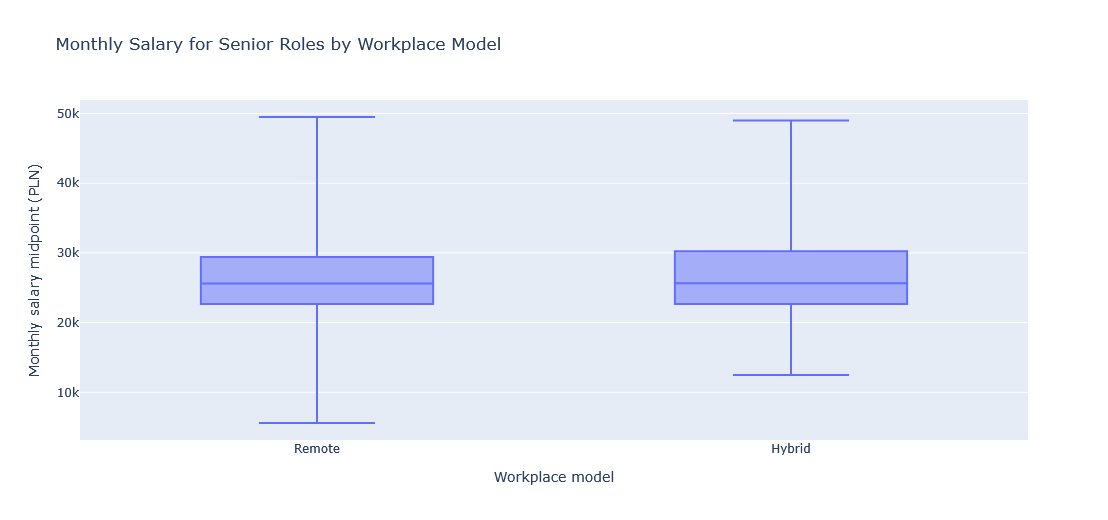

In [74]:
fig = px.box(
    senior_workplace_salary,
    x="workplace",
    y="salary_mid_pln_monthly",
    points=False,
    title="Monthly Salary for Senior Roles by Workplace Model",
    labels={
        "workplace": "Workplace model",
        "salary_mid_pln_monthly":
            "Monthly salary midpoint (PLN)",
    },
)

fig.update_layout(
    showlegend=False,
    height=520,
)

fig.show()

### Key observations

- Remote and Hybrid offers have very similar salary distributions, with overall medians of PLN 24,823 and PLN 24,360.
- Among Senior roles, the medians are almost identical: PLN 25,620 for Remote and PLN 25,650 for Hybrid.
- The data therefore provides no meaningful evidence of a Remote salary premium after controlling for experience at the Senior level.
- Onsite offers are excluded because the sample is too small for a reliable comparison.


### 7.6 Salary by company size

Compare salary distributions across known company-size segments. Offers with missing company size are excluded only from this comparison.


In [75]:
company_size_order = [
    "Small",
    "Medium",
    "Large",
    "Enterprise",
]

company_size_salary_df = salary_df.loc[
    salary_df["company_size_segment"].isin(
        company_size_order
    )
].copy()

In [76]:
salary_by_company_size = (
    company_size_salary_df
    .groupby(
        "company_size_segment",
        observed=True,
    )
    .agg(
        job_offers=("job_id", "nunique"),
        median_salary=(
            "salary_mid_pln_monthly",
            "median",
        ),
        q1_salary=(
            "salary_mid_pln_monthly",
            lambda x: x.quantile(0.25),
        ),
        q3_salary=(
            "salary_mid_pln_monthly",
            lambda x: x.quantile(0.75),
        ),
    )
    .round(0)
    .reset_index()
)

salary_by_company_size["company_size_segment"] = (
    pd.Categorical(
        salary_by_company_size[
            "company_size_segment"
        ],
        categories=company_size_order,
        ordered=True,
    )
)

salary_by_company_size = (
    salary_by_company_size
    .sort_values("company_size_segment")
)

salary_by_company_size

,company_size_segment,job_offers,median_salary,q1_salary,q3_salary
3,Small,128,25200.0,20475.0,28607.0
2,Medium,356,24430.0,20120.0,29122.0
1,Large,789,24360.0,20580.0,28560.0
0,Enterprise,410,22680.0,18882.0,27225.0


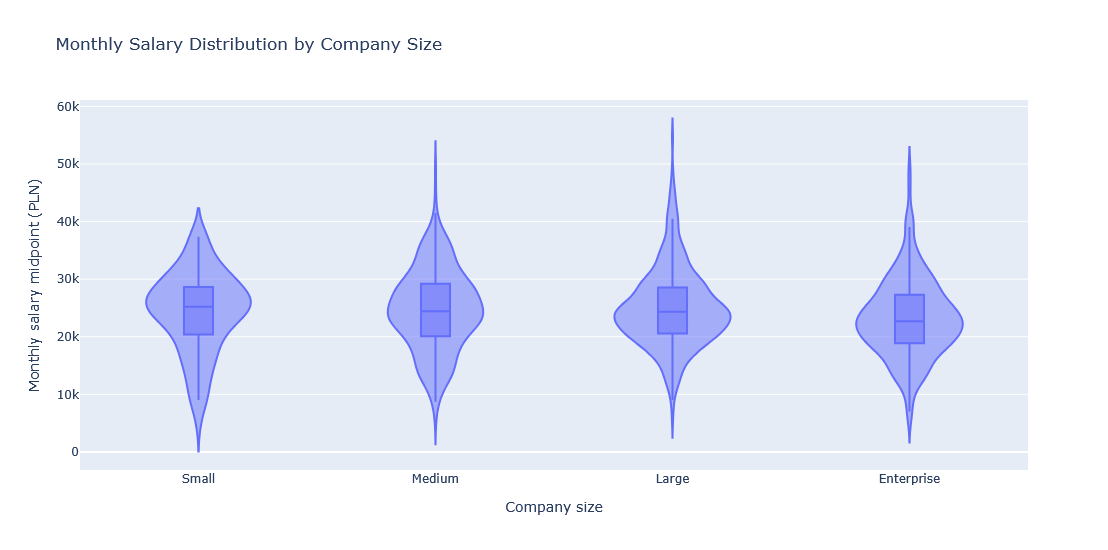

In [77]:
fig = px.violin(
    company_size_salary_df,
    x="company_size_segment",
    y="salary_mid_pln_monthly",
    category_orders={
        "company_size_segment":
            company_size_order,
    },
    box=True,
    points=False,
    title="Monthly Salary Distribution by Company Size",
    labels={
        "company_size_segment": "Company size",
        "salary_mid_pln_monthly":
            "Monthly salary midpoint (PLN)",
    },
)

fig.update_layout(
    showlegend=False,
    height=550,
)

fig.show()

### Key observations

- Small companies have the highest observed median salary at PLN 25,200.
- Medium and Large companies have similar medians of PLN 24,430 and PLN 24,360.
- Enterprise organizations have the lowest median at PLN 22,680.
- These differences are descriptive and may reflect variation in experience, categories and contract structures across company-size segments.


### 7.7 Salary by experience and contract type

Compare contract groups within the same experience levels to reduce confounding from experience composition.


In [78]:
experience_contract_salary = (
    contract_salary_plot
    .dropna(subset=["experience"])
    .groupby(
        [
            "experience",
            "contract_group",
        ],
        observed=True,
    )
    .agg(
        job_offers=("job_id", "nunique"),
        median_salary=(
            "salary_mid_pln_monthly",
            "median",
        ),
    )
    .reset_index()
)



experience_contract_salary[
    "median_salary"
] = (
    experience_contract_salary[
        "median_salary"
    ]
    .round(0)
)

experience_contract_salary

,experience,contract_group,job_offers,median_salary
0,Expert,B2B,60,31898.0
1,Expert,B2B + UoP,7,33600.0
2,Expert,UoP,3,24311.0
3,Junior,B2B,46,12600.0
4,Junior,B2B + UoP,12,18086.0
5,Junior,UoP,7,13225.0
6,Mid,B2B,578,21000.0
7,Mid,B2B + UoP,84,27300.0
8,Mid,UoP,27,26198.0
9,Senior,B2B,1016,25500.0


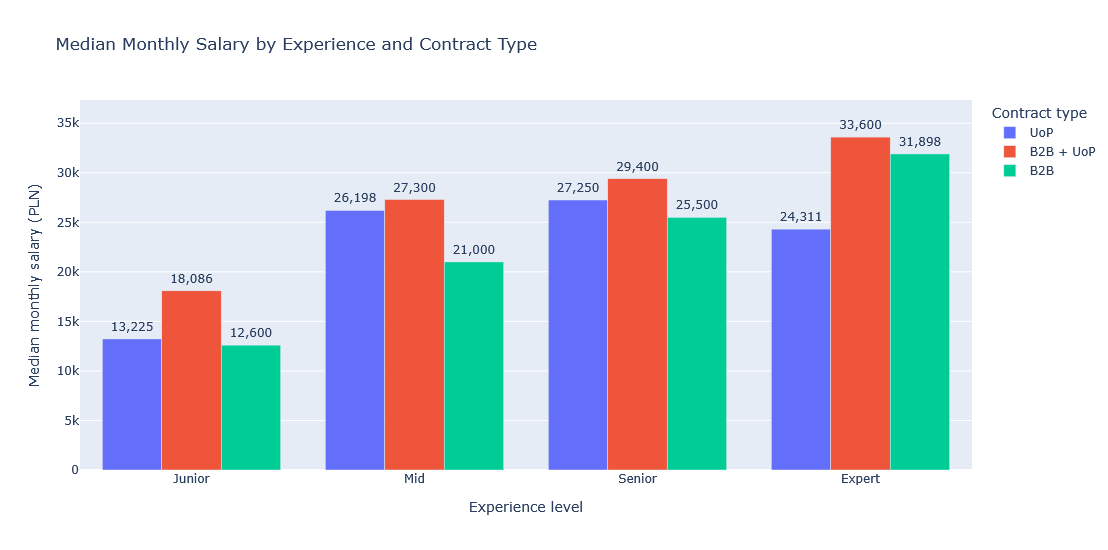

In [79]:
fig = px.bar(
    experience_contract_salary,
    x="experience",
    y="median_salary",
    color="contract_group",
    barmode="group",
    text="median_salary",
    category_orders={
        "experience": experience_order,
        "contract_group": [
            "UoP",
            "B2B + UoP",
            "B2B",
        ],
    },
    title="Median Monthly Salary by Experience and Contract Type",
    labels={
        "experience": "Experience level",
        "median_salary":
            "Median monthly salary (PLN)",
        "contract_group": "Contract type",
    },
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    height=550,
    legend_title_text="Contract type",
)

fig.show()

### Key observations

- Median salary generally increases with experience across all contract
  groups.
- Offers providing both B2B and UoP options have the highest median at
  every experience level.
- The difference between contract groups is particularly visible for
  Expert roles, where the median ranges from approximately PLN 24,311
  for UoP to PLN 33,600 for offers providing both options.
- B2B does not consistently provide the highest advertised salary:
  its median is below UoP for Junior, Mid and Senior roles.
- Results for combinations with small sample sizes should be treated
  as descriptive rather than representative.
- Contract amounts are not directly equivalent because B2B and UoP
  differ in taxation, paid leave, benefits and employer costs.

### 7.8 Salary-information availability

Measure whether salary transparency differs between experience levels and identify possible representation bias in salary comparisons.


In [80]:
salary_availability = (
    df.dropna(subset=["experience"])
    .groupby(
        "experience",
        observed=True,
    )
    .agg(
        all_offers=("job_id", "nunique"),
        offers_with_salary=(
            "salary_analysis_eligible",
            "sum",
        ),
    )
    .reset_index()
)

salary_availability["salary_available_pct"] = (
    salary_availability["offers_with_salary"]
    / salary_availability["all_offers"]
    * 100
).round(1)

salary_availability["experience"] = pd.Categorical(
    salary_availability["experience"],
    categories=experience_order,
    ordered=True,
)

salary_availability = (
    salary_availability
    .sort_values("experience")
)

salary_availability

,experience,all_offers,offers_with_salary,salary_available_pct
1,Junior,142,90,63.4
2,Mid,1230,805,65.4
3,Senior,1816,1358,74.8
0,Expert,144,99,68.8


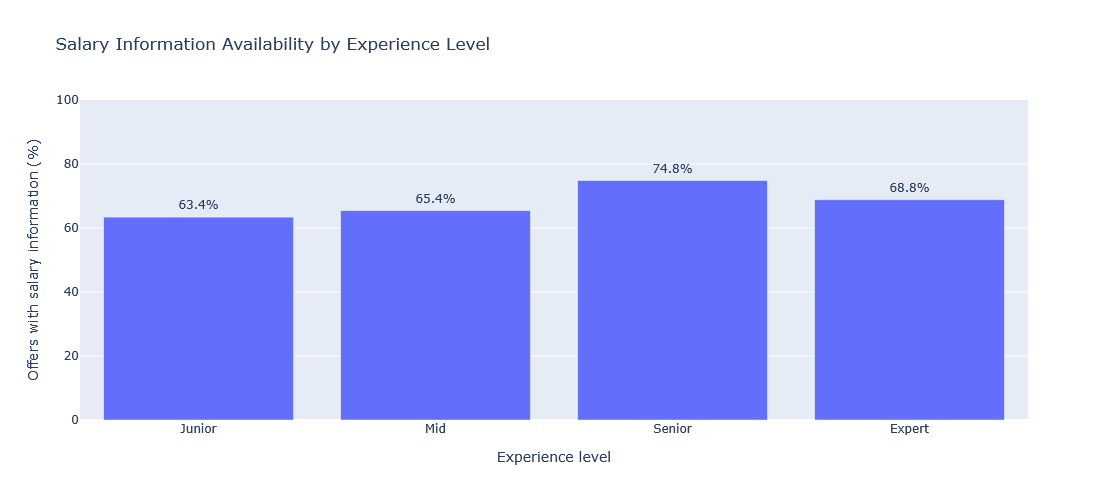

In [81]:
fig = px.bar(
    salary_availability,
    x="experience",
    y="salary_available_pct",
    text="salary_available_pct",
    category_orders={
        "experience": experience_order,
    },
    title="Salary Information Availability by Experience Level",
    labels={
        "experience": "Experience level",
        "salary_available_pct":
            "Offers with salary information (%)",
    },
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    showlegend=False,
    height=500,
    yaxis_range=[0, 100],
)

fig.show()

### Key observations

- Salary information is available for 74.8% of Senior offers, the highest
  share among all experience levels.
- Availability is lower for Expert roles (68.8%), Mid roles (65.4%) and
  Junior roles (63.4%).
- The difference between Senior and Junior positions is 11.4 percentage
  points.
- Senior roles are therefore slightly overrepresented in the salary
  analysis, while Junior roles are underrepresented.
- Salary comparisons should be interpreted with this difference in data
  availability in mind.

## 8. Location Analysis

This section examines the geographical distribution of job offers,
workplace models and salary differences across the most frequently
reported locations.

In [82]:
df['job_locations'] = df['job_locations'].replace('Warsaw, Poland', 'Warszawa')

In [83]:
df.loc[df['job_locations'].isna() & (df['workplace'] == "Remote"), 'job_locations'] = 'Remote'

In [84]:
only_cities = df[df['job_locations'] != "Remote"]

In [85]:
city_ranking = only_cities.groupby('job_locations')['job_id'].nunique()

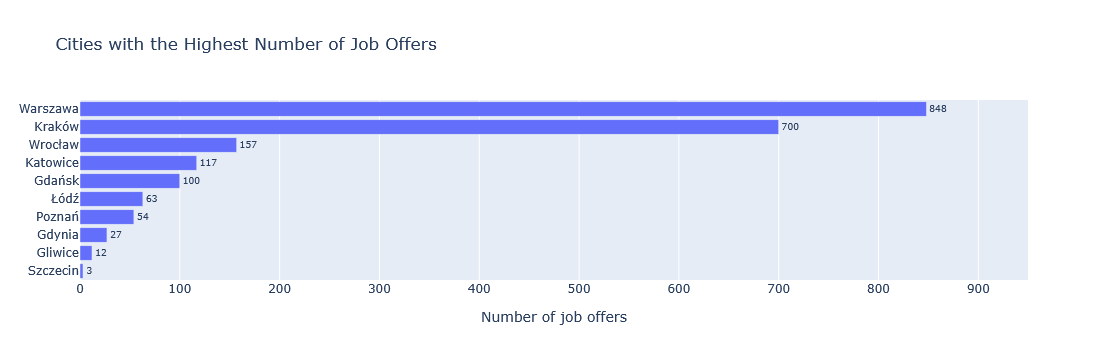

In [86]:
top_10_cities = (
    city_ranking
    .sort_values(ascending=False)
    .head(10)
    .rename("job_offers")
    .reset_index()
    .sort_values("job_offers")
)

fig = px.bar(
    top_10_cities,
    x="job_offers",
    y="job_locations",
    orientation="h",
    text="job_offers",
    title="Cities with the Highest Number of Job Offers",
    labels={
        "job_offers": "Number of job offers",
        "job_locations": "City",
    },
)

fig.update_traces(
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    showlegend=False,
    yaxis_title=None,
    xaxis_range=[
        0,
        top_10_cities["job_offers"].max() * 1.12,
    ],
)

fig.show()

In [87]:
top_8_cities = (
    city_ranking
    .sort_values(ascending=False)
    .head(8)
    .index
)

city_experience_df = (
    only_cities.loc[
        only_cities["job_locations"].isin(
            top_8_cities
        )
    ]
    .dropna(subset=["experience"])
)

In [88]:
city_experience = (
    pd.crosstab(
        city_experience_df["job_locations"],
        city_experience_df["experience"],
        normalize="index",
    )
    .mul(100)
    .round(1)
)

In [89]:
experience_order = [
    "Junior",
    "Mid",
    "Senior",
    "Expert",
]

city_experience = city_experience.reindex(
    index=top_8_cities,
    columns=experience_order,
    fill_value=0,
)

city_experience

experience,Junior,Mid,Senior,Expert
job_locations,,,,
Warszawa,4.0,43.9,49.0,3.1
Kraków,2.7,40.0,51.2,6.0
Wrocław,12.2,42.3,41.0,4.5
Katowice,16.2,41.9,36.8,5.1
Gdańsk,2.0,24.2,65.7,8.1
Łódź,9.6,34.6,50.0,5.8
Poznań,14.8,29.6,53.7,1.9
Gdynia,0.0,44.4,51.9,3.7


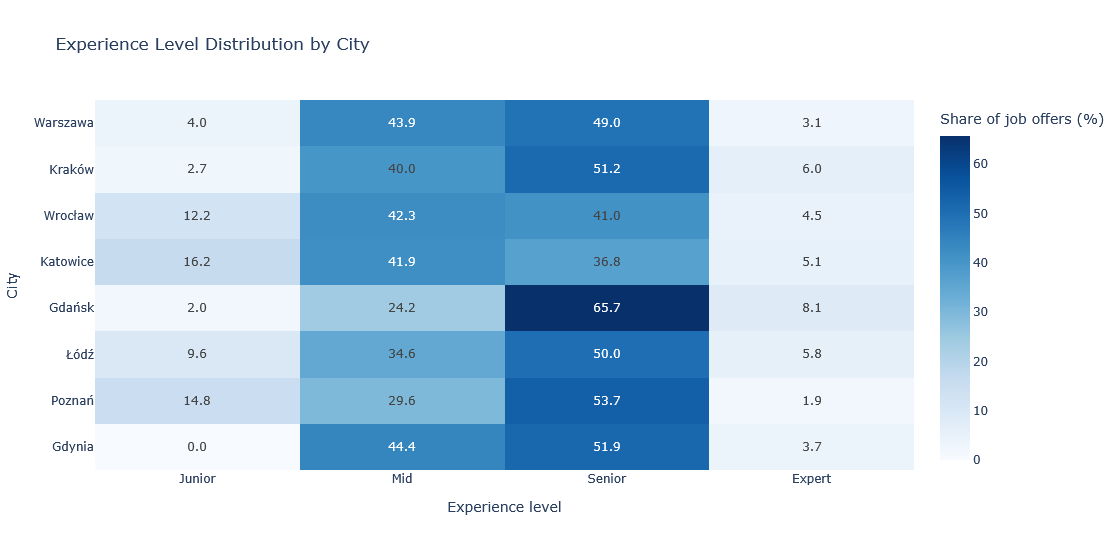

In [90]:
fig = px.imshow(
    city_experience,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Blues",
    title="Experience Level Distribution by City",
    labels={
        "x": "Experience level",
        "y": "City",
        "color": "Share of job offers (%)",
    },
)

fig.update_layout(
    height=550,
)

fig.show()

In [91]:
salary_location_df = (
    salary_df
    .drop(
        columns=["job_locations"],
        errors="ignore",
    )
    .merge(
        df[
            [
                "job_id",
                "job_locations",
            ]
        ],
        on="job_id",
        how="left",
        validate="one_to_one",
    )
)

salary_location_df = salary_location_df.loc[
    ~salary_location_df["job_locations"].isin(
        ["Remote", "Missing"]
    )
].copy()

In [92]:
salary_by_city = (
    salary_location_df
    .groupby("job_locations")
    .agg(
        job_offers=("job_id", "nunique"),
        median_salary=(
            "salary_mid_pln_monthly",
            "median",
        ),
        q1_salary=(
            "salary_mid_pln_monthly",
            lambda x: x.quantile(0.25),
        ),
        q3_salary=(
            "salary_mid_pln_monthly",
            lambda x: x.quantile(0.75),
        ),
    )
    .reset_index()
    .query("job_offers >= 30")
)

salary_by_city[
    [
        "median_salary",
        "q1_salary",
        "q3_salary",
    ]
] = (
    salary_by_city[
        [
            "median_salary",
            "q1_salary",
            "q3_salary",
        ]
    ]
    .round(0)
)

salary_by_city = salary_by_city.sort_values(
    "median_salary"
)

salary_by_city

,job_locations,job_offers,median_salary,q1_salary,q3_salary
7,Poznań,40,18106.0,13225.0,23794.0
4,Katowice,55,19320.0,14140.0,23510.0
13,Wrocław,100,19372.0,15000.0,22545.0
1,Gdańsk,54,23310.0,19395.0,27135.0
12,Warszawa,563,24360.0,20160.0,29400.0
5,Kraków,481,26250.0,22050.0,30975.0


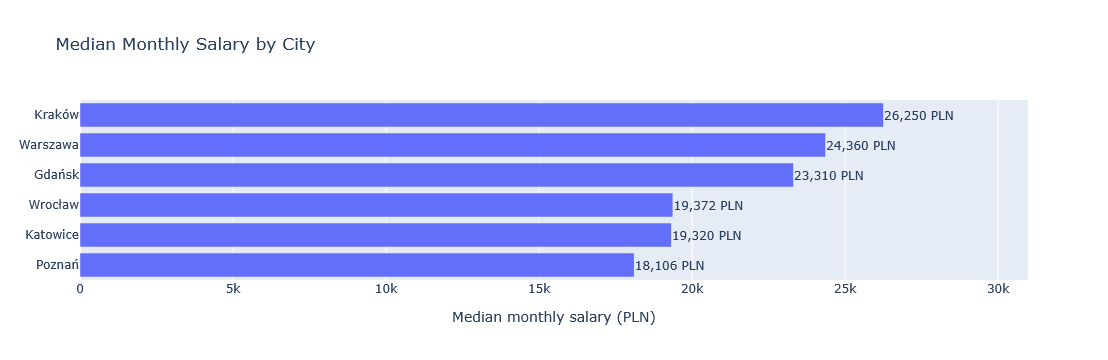

In [93]:
fig = px.bar(
    salary_by_city,
    x="median_salary",
    y="job_locations",
    orientation="h",
    text="median_salary",
    title="Median Monthly Salary by City",
    labels={
        "median_salary":
            "Median monthly salary (PLN)",
        "job_locations": "City",
    },
    hover_data={
        "job_offers": True,
        "q1_salary": ":,.0f",
        "q3_salary": ":,.0f",
        "median_salary": ":,.0f",
    },
)

fig.update_traces(
    texttemplate="%{text:,.0f} PLN",
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    showlegend=False,
    yaxis_title=None,
    xaxis_range=[
        0,
        salary_by_city[
            "median_salary"
        ].max() * 1.18,
    ],
)

fig.show()

In [94]:
senior_salary_by_city = (
    salary_location_df.loc[
        salary_location_df["experience"].eq(
            "Senior"
        )
    ]
    .groupby("job_locations")
    .agg(
        senior_offers=("job_id", "nunique"),
        senior_median_salary=(
            "salary_mid_pln_monthly",
            "median",
        ),
        senior_q1_salary=(
            "salary_mid_pln_monthly",
            lambda x: x.quantile(0.25),
        ),
        senior_q3_salary=(
            "salary_mid_pln_monthly",
            lambda x: x.quantile(0.75),
        ),
    )
    .reset_index()
    .query("senior_offers >= 20")
)

senior_salary_by_city[
    [
        "senior_median_salary",
        "senior_q1_salary",
        "senior_q3_salary",
    ]
] = (
    senior_salary_by_city[
        [
            "senior_median_salary",
            "senior_q1_salary",
            "senior_q3_salary",
        ]
    ]
    .round(0)
)

senior_salary_by_city = (
    senior_salary_by_city
    .sort_values("senior_median_salary")
)

senior_salary_by_city

,job_locations,senior_offers,senior_median_salary,senior_q1_salary,senior_q3_salary
8,Wrocław,40,22025.0,19830.0,25200.0
5,Poznań,22,23571.0,19125.0,28392.0
3,Katowice,20,23940.0,18750.0,25200.0
1,Gdańsk,37,24780.0,22208.0,31920.0
7,Warszawa,293,26040.0,22770.0,31080.0
4,Kraków,250,27000.0,23638.0,31306.0


In [95]:
city_salary_comparison = (
    salary_by_city[
        [
            "job_locations",
            "job_offers",
            "median_salary",
        ]
    ]
    .merge(
        senior_salary_by_city[
            [
                "job_locations",
                "senior_offers",
                "senior_median_salary",
            ]
        ],
        on="job_locations",
        how="inner",
    )
)

city_salary_comparison

,job_locations,job_offers,median_salary,senior_offers,senior_median_salary
0,Poznań,40,18106.0,22,23571.0
1,Katowice,55,19320.0,20,23940.0
2,Wrocław,100,19372.0,40,22025.0
3,Gdańsk,54,23310.0,37,24780.0
4,Warszawa,563,24360.0,293,26040.0
5,Kraków,481,26250.0,250,27000.0


In [96]:
city_salary_plot = (
    city_salary_comparison
    .melt(
        id_vars=[
            "job_locations",
            "job_offers",
            "senior_offers",
        ],
        value_vars=[
            "median_salary",
            "senior_median_salary",
        ],
        var_name="salary_group",
        value_name="median_salary_pln",
    )
)

city_salary_plot["salary_group"] = (
    city_salary_plot["salary_group"]
    .replace({
        "median_salary": "All experience levels",
        "senior_median_salary": "Senior only",
    })
)

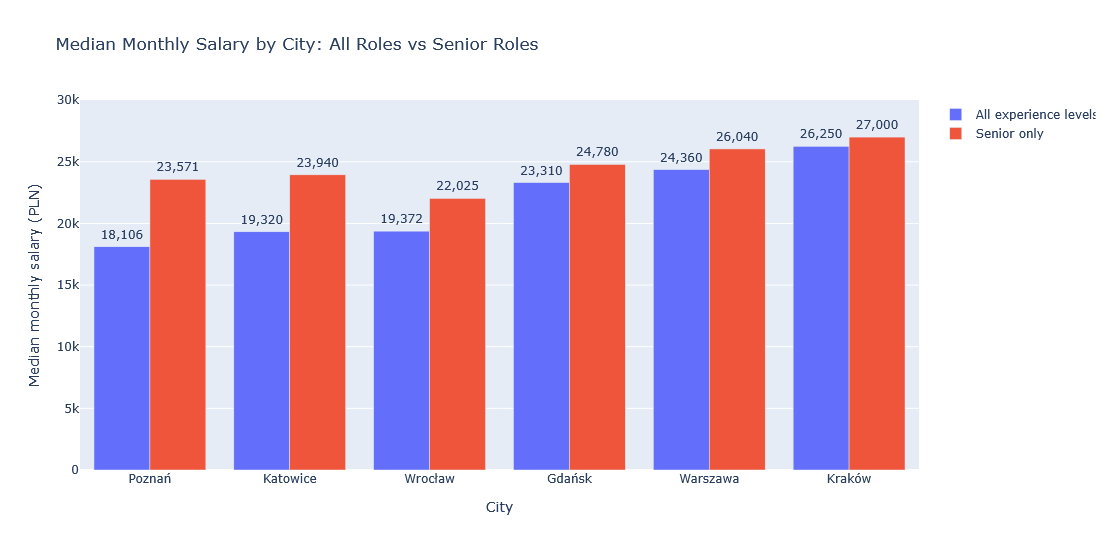

In [97]:
fig = px.bar(
    city_salary_plot,
    x="job_locations",
    y="median_salary_pln",
    color="salary_group",
    barmode="group",
    text="median_salary_pln",
    title="Median Monthly Salary by City: All Roles vs Senior Roles",
    labels={
        "job_locations": "City",
        "median_salary_pln":
            "Median monthly salary (PLN)",
        "salary_group": "Salary group",
    },
    hover_data={
        "job_offers": True,
        "senior_offers": True,
        "median_salary_pln": ":,.0f",
    },
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    height=550,
    legend_title_text=None,
)

fig.show()

### Key observations

- Among offers assigned to a physical city, Warsaw is the largest market
  with 848 offers, followed by Kraków with 700.
- Warsaw accounts for 40.5% of city-based offers. The three largest cities
  jointly account for approximately 81.4%, indicating strong geographical
  concentration.
- Warsaw has the largest absolute number of Junior opportunities, with
  34 offers. However, Junior roles represent a larger relative share in
  Katowice (16.2%), Poznań (14.8%) and Wrocław (12.2%).
- Gdańsk has the highest Senior concentration at 65.7%, although its total
  number of offers is much lower than in Warsaw or Kraków.
- Kraków has the highest overall median salary among sufficiently represented
  cities at PLN 26,250, followed by Warsaw at PLN 24,360.
- After restricting the comparison to Senior roles, Kraków remains the
  highest-paying city with a median of PLN 27,000, while Warsaw reaches
  PLN 26,040.
- Salary differences between the lower-ranked cities become smaller when
  only Senior roles are compared, indicating that experience composition
  explains part of the overall geographical salary differences.

## 9. Skills Analysis

This section examines the availability and structure of required and
optional skill information before identifying the most frequently
requested technologies.

In [98]:
skills_quality = pd.DataFrame({
    "column": [
        "required_skills",
        "nice_to_have",
    ],
    "available": [
        df["required_skills"].notna().sum(),
        df["nice_to_have"].notna().sum(),
    ],
    "missing": [
        df["required_skills"].isna().sum(),
        df["nice_to_have"].isna().sum(),
    ],
    "unique_values": [
        df["required_skills"].nunique(),
        df["nice_to_have"].nunique(),
    ],
})

skills_quality["available_pct"] = (
    skills_quality["available"]
    / len(df)
    * 100
).round(1)

skills_quality

,column,available,missing,unique_values,available_pct
0,required_skills,3352,8,3171,99.8
1,nice_to_have,2042,1318,1690,60.8


In [99]:
skills_sample = (
    df.loc[
        df["required_skills"].notna(),
        [
            "title",
            "category",
            "required_skills",
            "nice_to_have",
        ],
    ]
    .drop_duplicates(
        subset=["required_skills"]
    )
    .sample(
        n=min(
            30,
            df["required_skills"]
            .nunique(),
        ),
        random_state=42,
    )
)

skills_sample

,title,category,required_skills,nice_to_have
256,Business Analyst (Collateral Management),Business Analysis,Python pandas NumPy scikit-learn SQL Polski,NaN
2274,Senior DevOps Engineer,DevOps,AWS DevOps Terraform Docker IPAM Cloudflare Fi...,Ruby Golang AWS certificate GCP certificate
1000,IAM Domain Specialist,Backend,IAM Role-based access control Security IBM SAP...,Active Directory
971,Golang/Vue.js Senior Developer,Backend,Go Golang Vue.js Git Testing Integration test ...,Docker Kubernetes MongoDB OpenAPI AI
340,Cloud & Infrastructure Engineer,DevOps,DevOps SRE Kubernetes Docker Ingress Unix Linu...,Security RHCSA ArgoCD f.lux SaaS
1142,Java Developer (aplikacje mobilne),Backend,Java Android Studio Git REST API PostgreSQL Li...,IntelliJ Gradle Jenkins Tomcat Redmine React A...
2370,"Senior Fullstack Engineer - Node, React, Types...",Fullstack,FullStack Algorithmic thinking Data structures...,NaN
3313,UX Researcher,Design,UX design UX research Angielski,NaN
1464,Mobile Architect (Android/Kotlin) start ASAP,Mobile,Kotlin Android SDK Clean Architecture MVVM Git...,NaN
196,"AVP, Senior Engineer - AI & Data Science",AI,Data science AI Cloud Python Object-oriented p...,NaN


In [100]:
df["required_skills_length"] = (
    df["required_skills"]
    .fillna("")
    .str.len()
)

df["required_skills_length"].describe()

count    3360.000000
mean       79.167857
std        52.766059
min         0.000000
25%        42.000000
50%        67.000000
75%       101.000000
max       422.000000
Name: required_skills_length, dtype: float64

In [101]:
skill_candidates = [
    "Python",
    "SQL",
    "Java",
    "JavaScript",
    "TypeScript",
    "C#",
    "C++",
    ".NET",
    "React",
    "Angular",
    "Vue.js",
    "Node.js",
    "Spring",
    "Spring Boot",
    "pandas",
    "NumPy",
    "scikit-learn",
    "TensorFlow",
    "PyTorch",
    "Power BI",
    "Tableau",
    "Excel",
    "AWS",
    "Azure",
    "GCP",
    "Docker",
    "Kubernetes",
    "Terraform",
    "Git",
    "Jenkins",
    "Linux",
    "Spark",
    "Kafka",
    "Snowflake",
    "PostgreSQL",
    "MongoDB",
    "Oracle",
    "REST API",
    "Machine Learning",
]

In [102]:
skills_text = (
    df["required_skills"]
    .fillna("")
)

skill_frequency = []

for skill in skill_candidates:
    pattern = (
        rf"(?<!\w)"
        rf"{re.escape(skill)}"
        rf"(?!\w)"
    )

    job_offers = (
        skills_text
        .str.contains(
            pattern,
            case=False,
            regex=True,
        )
        .sum()
    )

    skill_frequency.append({
        "skill": skill,
        "job_offers": job_offers,
    })

skill_frequency = (
    pd.DataFrame(skill_frequency)
    .sort_values(
        "job_offers",
        ascending=False,
    )
    .reset_index(drop=True)
)

skill_frequency.head(20)

,skill,job_offers
0,Python,748
1,SQL,714
2,Java,565
3,Azure,441
4,REST API,373
5,AWS,352
6,Git,330
7,Kubernetes,326
8,Docker,260
9,Linux,248


In [103]:
top_15_skills = (
    skill_frequency
    .query("job_offers > 0")
    .head(15)
    .copy()
)

top_15_skills["offer_share_pct"] = (
    top_15_skills["job_offers"]
    / df["required_skills"].notna().sum()
    * 100
).round(1)

top_15_skills = (
    top_15_skills
    .sort_values("job_offers")
)

top_15_skills

,skill,job_offers,offer_share_pct
14,.NET,199,5.9
13,GCP,203,6.1
12,JavaScript,211,6.3
11,TypeScript,222,6.6
10,Spring,226,6.7
9,Linux,248,7.4
8,Docker,260,7.8
7,Kubernetes,326,9.7
6,Git,330,9.8
5,AWS,352,10.5


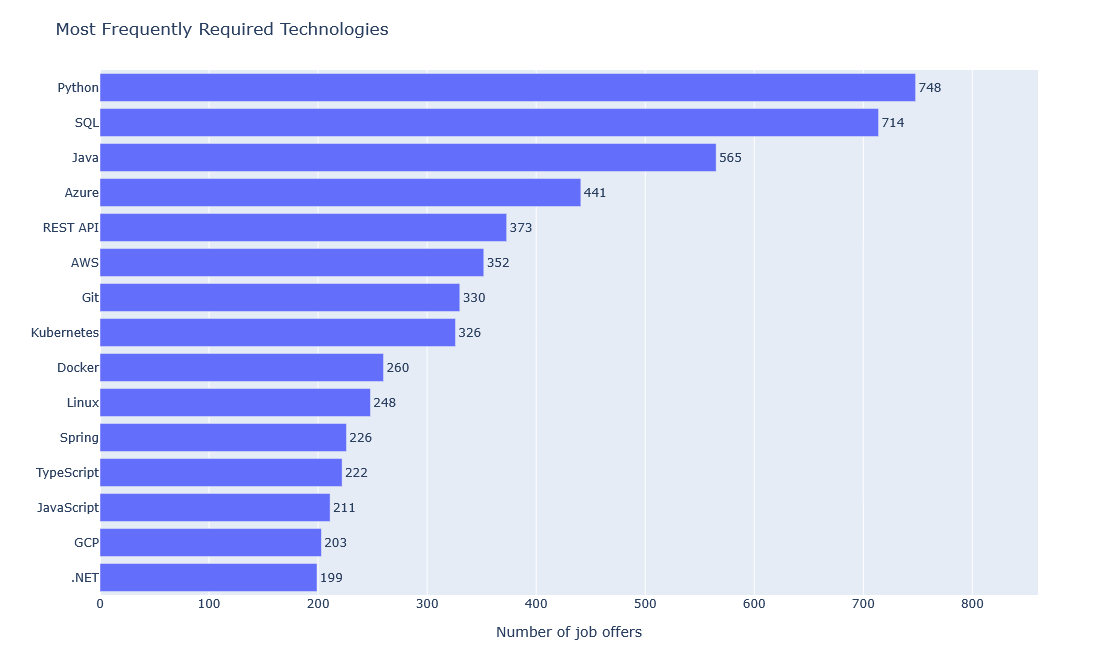

In [104]:
fig = px.bar(
    top_15_skills,
    x="job_offers",
    y="skill",
    orientation="h",
    text="job_offers",
    title="Most Frequently Required Technologies",
    labels={
        "job_offers": "Number of job offers",
        "skill": "Technology",
    },
    hover_data={
        "offer_share_pct": ":.1f",
    },
)

fig.update_traces(
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    showlegend=False,
    height=650,
    margin=dict(
        l=100,
        r=70,
        t=70,
        b=50,
    ),
    yaxis=dict(
        title=None,
        tickmode="array",
        tickvals=top_15_skills["skill"],
        ticktext=top_15_skills["skill"],
        automargin=True,
    ),
    xaxis_range=[
        0,
        top_15_skills["job_offers"].max() * 1.15,
    ],
)

fig.show()

In [105]:
skill_rows = []

for skill in skill_candidates:
    pattern = (
        rf"(?<!\w)"
        rf"{re.escape(skill)}"
        rf"(?!\w)"
    )

    skill_mask = (
        df["required_skills"]
        .fillna("")
        .str.contains(
            pattern,
            case=False,
            regex=True,
        )
    )

    skill_rows.append(
        df.loc[
            skill_mask,
            [
                "job_id",
                "experience",
                "category",
                "salary_mid_pln_monthly",
                "salary_analysis_eligible",
            ],
        ]
        .assign(skill=skill)
    )

skills_long = (
    pd.concat(
        skill_rows,
        ignore_index=True,
    )
    .drop_duplicates(
        subset=[
            "job_id",
            "skill",
        ]
    )
)

skills_long.head()

,job_id,experience,category,salary_mid_pln_monthly,salary_analysis_eligible,skill
0,administrator-systemow-it-upvanta-wroclaw,Mid,Sys. Administrator,12075.0,True,Python
1,administrator-systemow-kubernetes-linux-aws-up...,Mid,Sys. Administrator,12075.0,True,Python
2,administrator-systemow-linux-unity-t-group-kra...,Mid,Sys. Administrator,12500.0,True,Python
3,agentic-ai-technical-consultant-poland-deloitt...,Mid,AI,NaN,False,Python
4,agentic-ai-technical-senior-consultant-poland-...,Senior,AI,NaN,False,Python


In [106]:
print("Unique offers:", skills_long["job_id"].nunique())
print("Offer-skill pairs:", len(skills_long))
print("Recognized technologies:", skills_long["skill"].nunique())

Unique offers: 2381
Offer-skill pairs: 7598
Recognized technologies: 39


In [107]:
top_10_skill_names = (
    skill_frequency
    .query("job_offers > 0")
    .head(10)["skill"]
    .tolist()
)

In [108]:
skill_experience_counts = (
    skills_long.loc[
        skills_long["skill"].isin(
            top_10_skill_names
        )
    ]
    .dropna(subset=["experience"])
    .groupby(
        [
            "skill",
            "experience",
        ]
    )["job_id"]
    .nunique()
    .unstack(fill_value=0)
)

In [109]:
experience_offer_counts = (
    df.loc[
        df["required_skills"].notna()
        & df["experience"].notna()
    ]
    .groupby("experience")["job_id"]
    .nunique()
)

In [110]:
skill_experience_pct = (
    skill_experience_counts
    .div(
        experience_offer_counts,
        axis="columns",
    )
    .mul(100)
    .round(1)
)

skill_experience_pct = skill_experience_pct.reindex(
    index=top_10_skill_names,
    columns=[
        "Junior",
        "Mid",
        "Senior",
        "Expert",
    ],
    fill_value=0,
)

skill_experience_pct

experience,Junior,Mid,Senior,Expert
skill,,,,
Python,14.8,20.0,24.6,21.5
SQL,16.2,23.1,20.8,17.4
Java,13.4,14.6,18.8,13.2
Azure,7.0,11.2,14.8,17.4
REST API,4.2,11.0,12.1,6.9
AWS,5.6,7.2,13.1,12.5
Git,7.7,10.0,10.5,2.8
Kubernetes,8.5,7.7,11.0,13.9
Docker,8.5,6.9,8.6,4.9


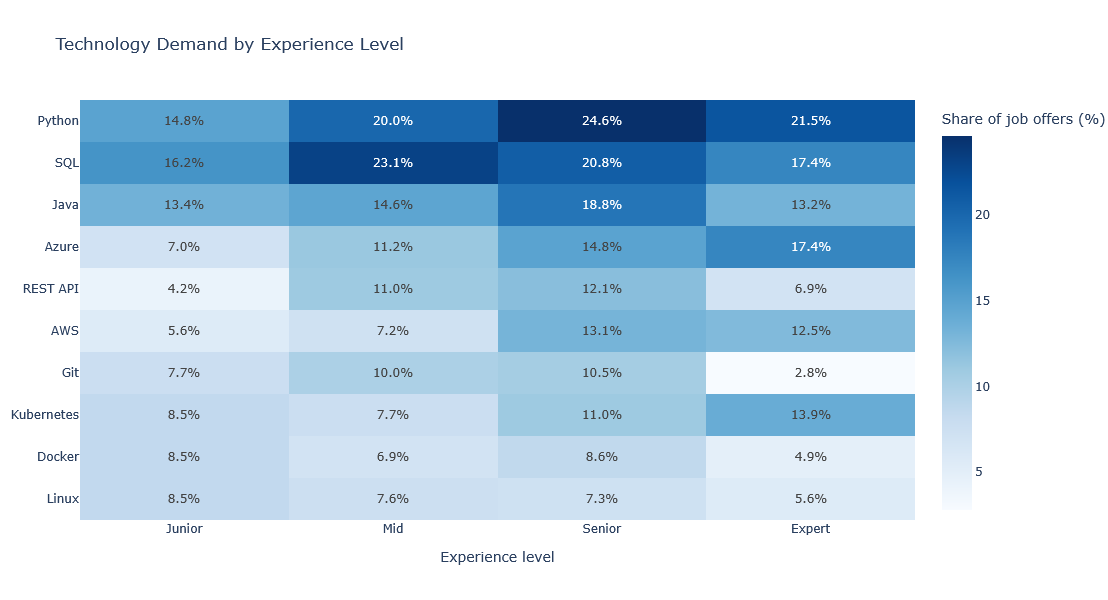

In [111]:
fig = px.imshow(
    skill_experience_pct,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Blues",
    title="Technology Demand by Experience Level",
    labels={
        "x": "Experience level",
        "y": "Technology",
        "color": "Share of job offers (%)",
    },
)

fig.update_traces(
    texttemplate="%{z:.1f}%"
)

fig.update_layout(
    height=600,
    yaxis_title=None,
)

fig.show()

In [112]:
top_8_categories = (
    df["category"]
    .value_counts()
    .head(8)
    .index
)

In [113]:
skill_category_counts = (
    skills_long.loc[
        skills_long["skill"].isin(
            top_10_skill_names
        )
        & skills_long["category"].isin(
            top_8_categories
        )
    ]
    .groupby(
        [
            "skill",
            "category",
        ]
    )["job_id"]
    .nunique()
    .unstack(fill_value=0)
)

In [114]:
category_offer_counts = (
    df.loc[
        df["required_skills"].notna()
        & df["category"].isin(
            top_8_categories
        )
    ]
    .groupby("category")["job_id"]
    .nunique()
)

In [115]:
skill_category_pct = (
    skill_category_counts
    .div(
        category_offer_counts,
        axis="columns",
    )
    .mul(100)
    .round(1)
)

skill_category_pct = skill_category_pct.reindex(
    index=top_10_skill_names,
    columns=top_8_categories,
    fill_value=0,
)

skill_category_pct

category,Backend,Data,Testing,DevOps,Fullstack,AI,ERP,Project Manager
skill,,,,,,,,
Python,19.0,47.4,19.9,34.5,24.1,66.1,0.0,1.2
SQL,26.5,54.7,23.3,7.2,35.6,14.5,6.3,0.6
Java,43.4,8.1,22.9,8.0,37.9,5.9,1.7,1.8
Azure,10.0,17.7,12.0,29.9,14.6,24.2,4.6,4.2
REST API,22.8,4.9,13.9,2.3,26.1,7.5,7.4,1.2
AWS,12.4,11.9,2.6,31.4,14.6,17.7,0.0,1.2
Git,15.3,7.2,15.4,12.9,21.3,11.8,2.3,0.0
Kubernetes,13.3,3.0,1.5,44.7,13.8,12.4,0.0,1.2
Docker,14.1,4.4,3.4,18.9,19.4,10.2,0.0,1.2


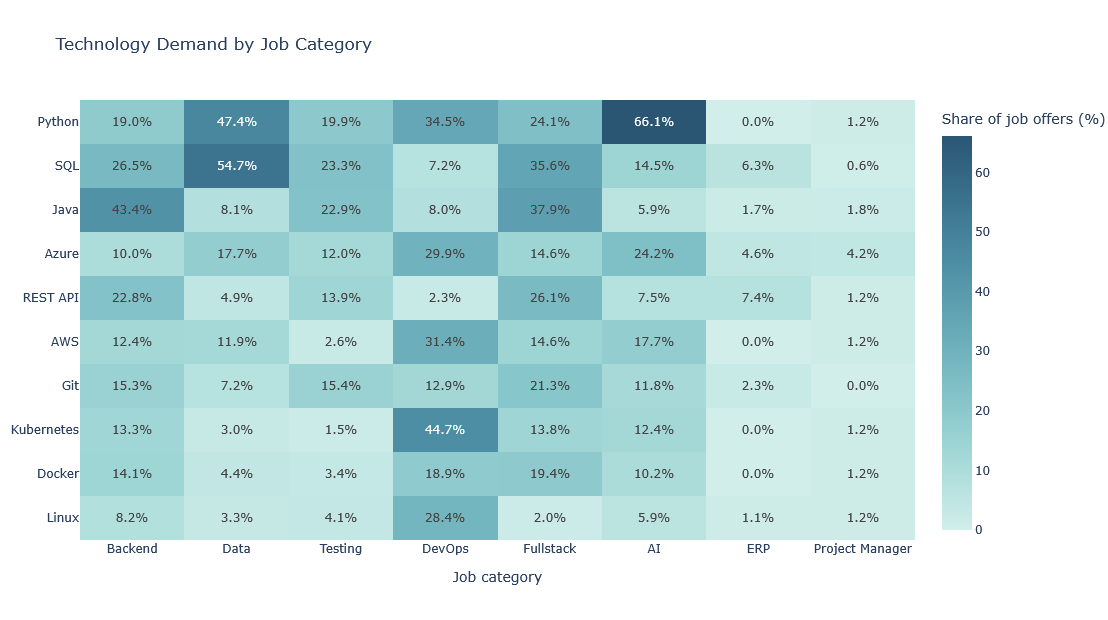

In [116]:
fig = px.imshow(
    skill_category_pct,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Teal",
    title="Technology Demand by Job Category",
    labels={
        "x": "Job category",
        "y": "Technology",
        "color": "Share of job offers (%)",
    },
)

fig.update_traces(
    texttemplate="%{z:.1f}%"
)

fig.update_layout(
    height=620,
    yaxis_title=None,
)

fig.show()

In [117]:
skill_salary_df = skills_long.loc[
    skills_long["salary_analysis_eligible"]
    & skills_long[
        "salary_mid_pln_monthly"
    ].between(
        5000,
        100000,
    )
].copy()

In [118]:
salary_by_skill = (
    skill_salary_df
    .groupby("skill")
    .agg(
        job_offers=("job_id", "nunique"),
        median_salary=(
            "salary_mid_pln_monthly",
            "median",
        ),
        q1_salary=(
            "salary_mid_pln_monthly",
            lambda x: x.quantile(0.25),
        ),
        q3_salary=(
            "salary_mid_pln_monthly",
            lambda x: x.quantile(0.75),
        ),
    )
    .reset_index()
    .query("job_offers >= 30")
)

salary_by_skill[
    [
        "median_salary",
        "q1_salary",
        "q3_salary",
    ]
] = (
    salary_by_skill[
        [
            "median_salary",
            "q1_salary",
            "q3_salary",
        ]
    ]
    .round(0)
)

salary_by_skill = salary_by_skill.sort_values(
    "median_salary"
)

salary_by_skill

,skill,job_offers,median_salary,q1_salary,q3_salary
7,Excel,50,22050.0,18480.0,26119.0
4,C#,121,23016.0,19320.0,28350.0
9,Git,248,23062.0,19320.0,26155.0
0,.NET,154,23520.0,20152.0,28410.0
5,C++,61,23520.0,19000.0,27500.0
2,Angular,78,23520.0,21000.0,26188.0
15,Linux,179,23625.0,18490.0,27720.0
27,SQL,526,23845.0,20000.0,27720.0
20,Oracle,76,23940.0,20160.0,27200.0
11,JavaScript,150,23970.0,20115.0,28350.0


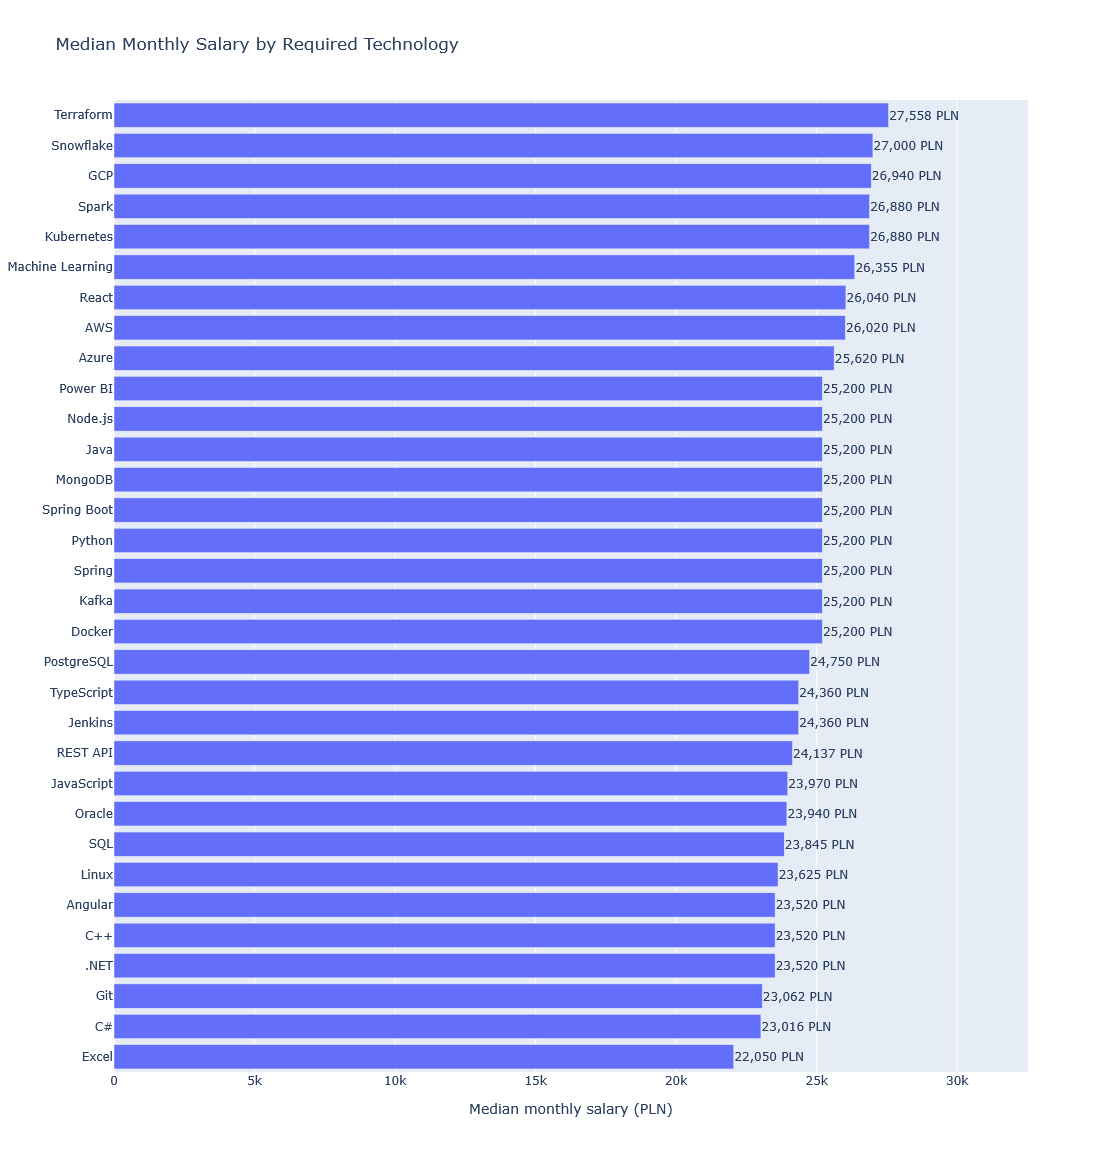

In [119]:
fig = px.bar(
    salary_by_skill,
    x="median_salary",
    y="skill",
    orientation="h",
    text="median_salary",
    title="Median Monthly Salary by Required Technology",
    labels={
        "median_salary":
            "Median monthly salary (PLN)",
        "skill": "Technology",
    },
    hover_data={
        "job_offers": True,
        "q1_salary": ":,.0f",
        "q3_salary": ":,.0f",
    },
)

fig.update_traces(
    texttemplate="%{text:,.0f} PLN",
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    showlegend=False,
    height=max(
        550,
        len(salary_by_skill) * 36,
    ),
    yaxis_title=None,
    xaxis_range=[
        0,
        salary_by_skill[
            "median_salary"
        ].max() * 1.18,
    ],
)

fig.show()

In [120]:
senior_salary_by_skill = (
    skill_salary_df.loc[
        skill_salary_df["experience"].eq(
            "Senior"
        )
    ]
    .groupby("skill")
    .agg(
        senior_offers=("job_id", "nunique"),
        senior_median_salary=(
            "salary_mid_pln_monthly",
            "median",
        ),
    )
    .reset_index()
    .query("senior_offers >= 20")
)

senior_salary_by_skill[
    "senior_median_salary"
] = (
    senior_salary_by_skill[
        "senior_median_salary"
    ]
    .round(0)
)

In [121]:
skill_salary_comparison = (
    salary_by_skill[
        [
            "skill",
            "job_offers",
            "median_salary",
        ]
    ]
    .merge(
        senior_salary_by_skill,
        on="skill",
        how="inner",
    )
    .sort_values(
        "senior_median_salary"
    )
)

skill_salary_comparison

,skill,job_offers,median_salary,senior_offers,senior_median_salary
0,Excel,50,22050.0,23,23100.0
5,Angular,78,23520.0,49,23940.0
2,Git,248,23062.0,147,24360.0
1,C#,121,23016.0,67,24360.0
10,REST API,299,24137.0,186,24360.0
8,Oracle,76,23940.0,43,24360.0
12,TypeScript,164,24360.0,103,24450.0
9,JavaScript,150,23970.0,90,24780.0
11,Jenkins,123,24360.0,76,24780.0
13,PostgreSQL,145,24750.0,96,24890.0


In [122]:
skill_salary_plot = (
    skill_salary_comparison
    .melt(
        id_vars=[
            "skill",
            "job_offers",
            "senior_offers",
        ],
        value_vars=[
            "median_salary",
            "senior_median_salary",
        ],
        var_name="salary_group",
        value_name="median_salary_pln",
    )
)

skill_salary_plot["salary_group"] = (
    skill_salary_plot["salary_group"]
    .replace({
        "median_salary":
            "All experience levels",
        "senior_median_salary":
            "Senior only",
    })
)

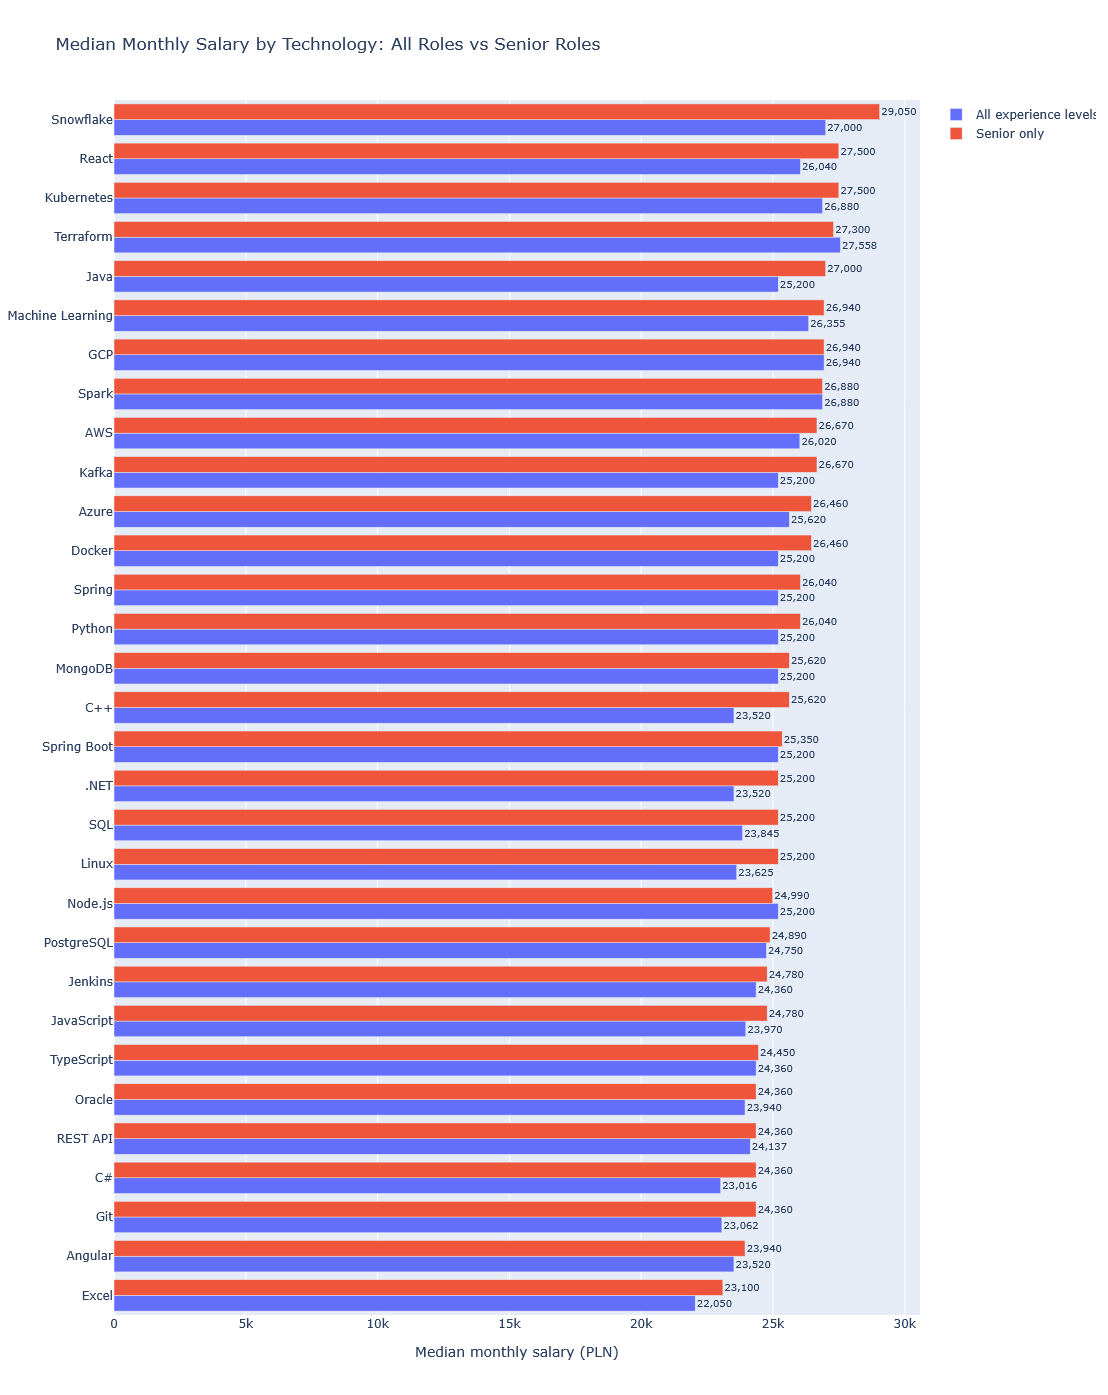

In [123]:
fig = px.bar(
    skill_salary_plot,
    x="median_salary_pln",
    y="skill",
    color="salary_group",
    orientation="h",
    barmode="group",
    text="median_salary_pln",
    title=(
        "Median Monthly Salary by Technology: "
        "All Roles vs Senior Roles"
    ),
    labels={
        "median_salary_pln":
            "Median monthly salary (PLN)",
        "skill": "Technology",
        "salary_group": "Salary group",
    },
    hover_data={
        "job_offers": True,
        "senior_offers": True,
    },
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    height=max(
        600,
        len(
            skill_salary_comparison
        ) * 45,
    ),
    yaxis_title=None,
    legend_title_text=None,
)

fig.show()

In [124]:
from itertools import combinations
from collections import Counter

In [125]:
skills_per_offer = (
    skills_long
    .groupby("job_id")["skill"]
    .apply(
        lambda skills:
            sorted(set(skills))
    )
)

In [126]:
skill_pair_counter = Counter()

for skills in skills_per_offer:
    skill_pair_counter.update(
        combinations(skills, 2)
    )

In [127]:
skill_pairs = pd.DataFrame(
    [
        {
            "skill_1": pair[0],
            "skill_2": pair[1],
            "job_offers": count,
        }
        for pair, count
        in skill_pair_counter.items()
    ]
)

spring_boot_pair = (
    skill_pairs[
        [
            "skill_1",
            "skill_2",
        ]
    ]
    .apply(
        lambda row: set(row) == {
            "Spring",
            "Spring Boot",
        },
        axis=1,
    )
)

skill_pairs = (
    skill_pairs.loc[
        ~spring_boot_pair
    ]
    .sort_values(
        "job_offers",
        ascending=False,
    )
    .reset_index(drop=True)
)

skill_pairs["skill_pair"] = (
    skill_pairs["skill_1"]
    + " + "
    + skill_pairs["skill_2"]
)

skill_pairs.head(20)

,skill_1,skill_2,job_offers,skill_pair
0,Python,SQL,247,Python + SQL
1,Java,Spring,217,Java + Spring
2,Java,SQL,154,Java + SQL
3,Java,Spring Boot,150,Java + Spring Boot
4,Docker,Kubernetes,148,Docker + Kubernetes
5,Azure,Python,148,Azure + Python
6,AWS,Python,139,AWS + Python
7,Java,REST API,134,Java + REST API
8,REST API,SQL,133,REST API + SQL
9,.NET,C#,120,.NET + C#


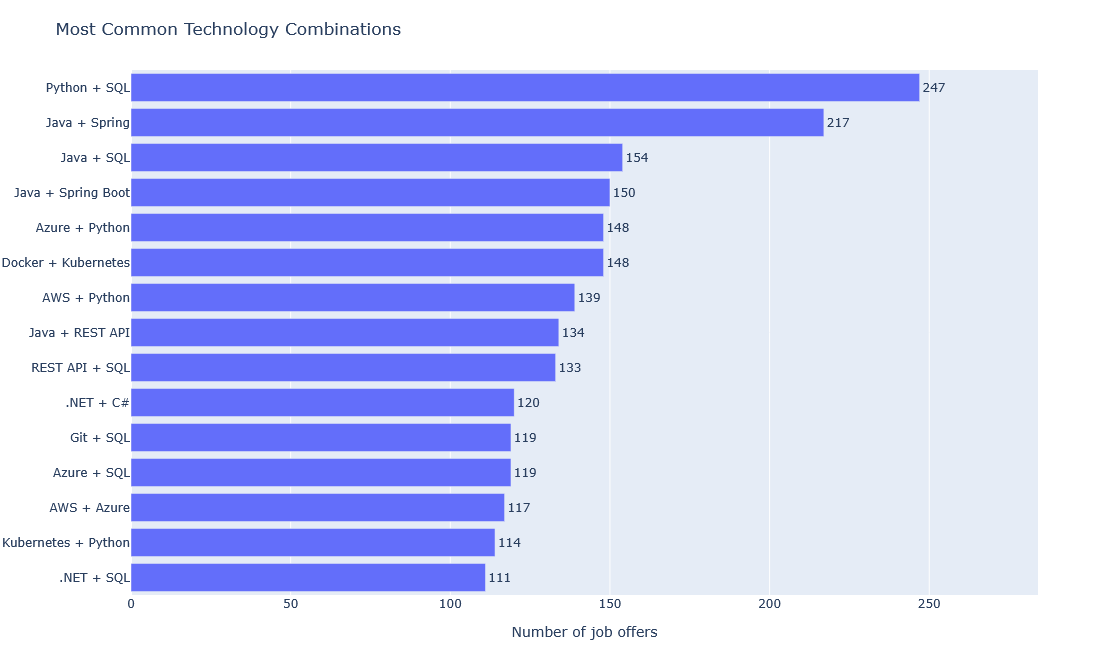

In [128]:
top_15_skill_pairs = (
    skill_pairs
    .head(15)
    .sort_values("job_offers")
)

fig = px.bar(
    top_15_skill_pairs,
    x="job_offers",
    y="skill_pair",
    orientation="h",
    text="job_offers",
    title="Most Common Technology Combinations",
    labels={
        "job_offers": "Number of job offers",
        "skill_pair": "Technology combination",
    },
)

fig.update_traces(
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    showlegend=False,
    height=650,
    yaxis_title=None,
    margin=dict(
        l=130,
        r=70,
        t=70,
        b=50,
    ),
    xaxis_range=[
        0,
        top_15_skill_pairs[
            "job_offers"
        ].max() * 1.15,
    ],
)

fig.show()

In [129]:
optional_skills_text = (
    df["nice_to_have"]
    .fillna("")
)

skill_requirement_comparison = []

for skill in skill_candidates:
    pattern = (
        rf"(?<!\w)"
        rf"{re.escape(skill)}"
        rf"(?!\w)"
    )

    required_count = (
        df["required_skills"]
        .fillna("")
        .str.contains(
            pattern,
            case=False,
            regex=True,
        )
        .sum()
    )

    optional_count = (
        optional_skills_text
        .str.contains(
            pattern,
            case=False,
            regex=True,
        )
        .sum()
    )

    skill_requirement_comparison.append({
        "skill": skill,
        "Required": required_count,
        "Nice to have": optional_count,
    })

In [130]:
skill_requirement_comparison = (
    pd.DataFrame(
        skill_requirement_comparison
    )
)

skill_requirement_comparison[
    "total_mentions"
] = (
    skill_requirement_comparison["Required"]
    + skill_requirement_comparison["Nice to have"]
)

top_skill_requirement_comparison = (
    skill_requirement_comparison
    .sort_values(
        "total_mentions",
        ascending=False,
    )
    .head(15)
)

In [131]:
skill_requirement_plot = (
    top_skill_requirement_comparison
    .melt(
        id_vars="skill",
        value_vars=[
            "Required",
            "Nice to have",
        ],
        var_name="requirement_type",
        value_name="job_offers",
    )
)

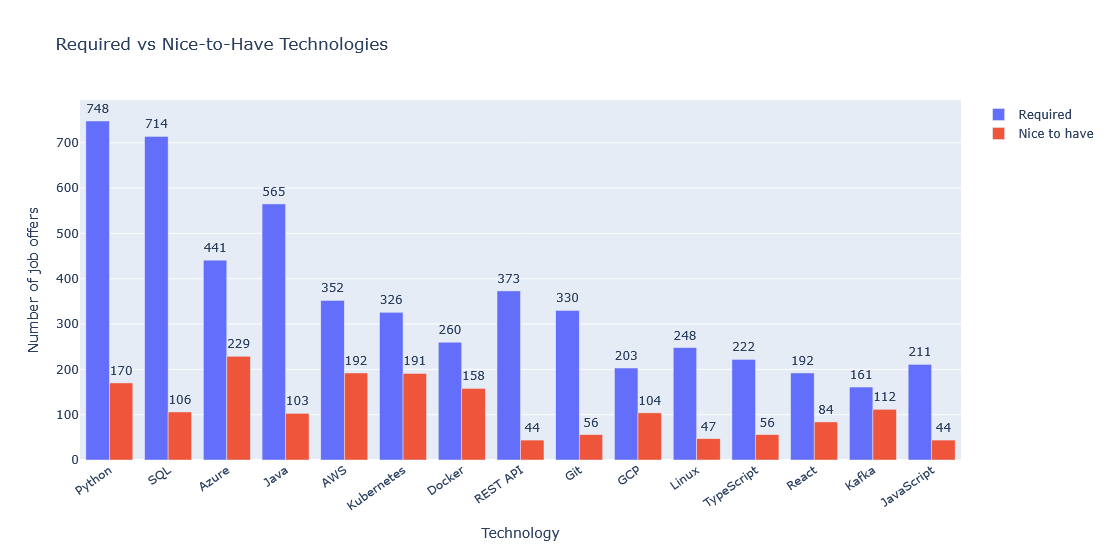

In [132]:
fig = px.bar(
    skill_requirement_plot,
    x="skill",
    y="job_offers",
    color="requirement_type",
    barmode="group",
    text="job_offers",
    title="Required vs Nice-to-Have Technologies",
    labels={
        "skill": "Technology",
        "job_offers": "Number of job offers",
        "requirement_type": "Requirement type",
    },
)

fig.update_traces(
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    height=550,
    xaxis_tickangle=-35,
    legend_title_text=None,
)

fig.show()

### Key observations

- Python is the most frequently identified technology, appearing in 748
  offers (22.3% of offers with available required-skills information).
  SQL follows closely with 714 offers (21.3%), while Java appears in 565
  offers (16.9%).
- Cloud and infrastructure technologies are also prominent. Azure appears
  in 441 offers, AWS in 352 and Kubernetes in 326.
- Technology demand differs strongly between job categories. Python appears
  in 66.1% of AI and 47.4% of Data offers, while SQL appears in 54.7% of
  Data offers. Java is particularly important in Backend roles, at 43.4%.
- DevOps roles show the strongest demand for Kubernetes (44.7%), followed
  by Python, AWS, Azure and Linux.
- Terraform has the highest overall median salary among sufficiently
  represented technologies at approximately PLN 27,558. Snowflake, GCP,
  Kubernetes and Spark also rank highly.
- Salary differences become smaller when only Senior offers are compared.
  This indicates that part of the overall technology salary premium results
  from differences in experience composition.
- Python and SQL form the most frequent technology combination, appearing
  together in 247 offers. Java frequently co-occurs with Spring, SQL and
  REST API, while Docker and Kubernetes form a common infrastructure pair.
- Azure, AWS, Kubernetes, Python and Docker are among the most frequent
  optional technologies, indicating that cloud skills often broaden a
  candidate's fit even when they are not mandatory.

## 10. Final Conclusions and Limitations

### Overall conclusions

- The analyzed dataset contains 3,360 IT job offers collected from No Fluff
  Jobs between August 24 and August 26, 2026.
- Recruitment activity is strongly oriented toward experienced candidates.
  Senior and Mid-level positions jointly account for 90.6% of all offers,
  while Junior roles represent only 4.2%.
- Hybrid work is the dominant workplace model, accounting for 56.0% of
  offers. Remote work represents 35.1% and is more frequently available
  to Senior candidates than to Junior candidates.
- Backend is the largest job category, followed by Data, Testing, DevOps
  and Fullstack. Junior opportunities remain limited across all leading
  categories.
- B2B is the most frequently reported contract type, appearing as the only
  option in 67.1% of offers. Contract information is missing for 22.9%
  of the dataset.
- Recruitment activity is concentrated among a small group of organizations.
  The 10 most active companies account for 37.2% of offers, while 40.8%
  of companies published only one offer.
- The median standardized monthly salary midpoint is approximately
  PLN 24,360. Median salary increases from PLN 13,225 for Junior roles
  to PLN 30,240 for Expert positions.
- Architecture and ERP have the highest median salaries among sufficiently
  represented job categories. After restricting the comparison to Senior
  roles, both categories remain among the highest-paying areas.
- Remote and Hybrid offers have similar salary distributions. Among Senior
  roles, their median monthly salary midpoints are almost identical, so the
  data does not indicate a clear Remote salary premium.
- Warsaw and Kraków dominate the geographical market. Warsaw accounts for
  40.5% of city-based offers, while the three largest cities jointly account
  for approximately 81.4%.
- Kraków has the highest overall median salary among sufficiently represented
  cities at PLN 26,250. It also remains the highest after restricting the
  comparison to Senior positions.
- Python, SQL and Java are the most frequently identified technologies.
  Python appears in 22.3% of offers with available skill information, while
  SQL appears in 21.3% and Java in 16.9%.
- Technology demand differs substantially between categories. Python and SQL
  dominate Data and AI roles, Java is particularly important in Backend,
  and Kubernetes is strongly associated with DevOps.
- Terraform, Snowflake, GCP, Kubernetes and Spark are associated with some
  of the highest advertised median salaries. However, part of this difference
  is explained by the experience composition of the corresponding offers.